# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)


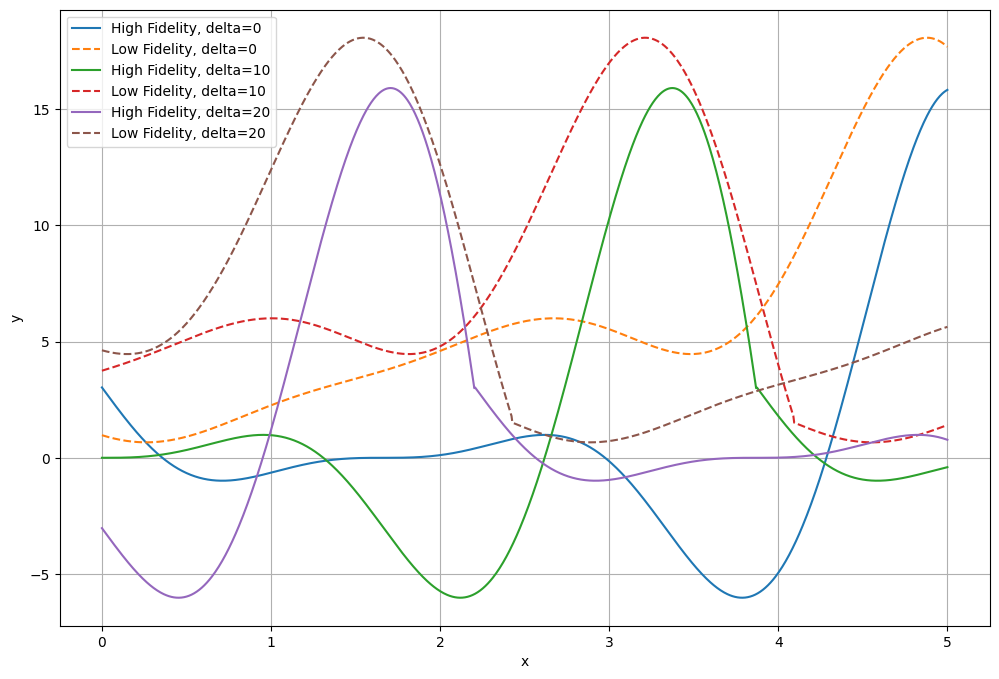

In [3]:
highfid = lambda x,delta: (6.*(x+delta/6)/5-2.)**2 * np.sin(12.*(x+delta/6)/5-4.)

lowfid = lambda x, delta: 0.5*highfid(x, delta) + 10*((x-delta/6)/5-0.5) + 5.
# Period of repetition
period = 5.54

# Modified function with periodicity
def modified_highfid(x,delta):
    # Calculate the phase within each period
    phase_within_period = np.mod(x+delta/6, period)
    
    # Calculate the original function for the given phase
    original_value = (6.*phase_within_period/5-2.)**2 * np.sin(12.*phase_within_period/5-4.)
    
    return original_value

period2=5.96

# Modified function with periodicity
def modified_lowfid(x,delta):
    # Calculate the phase within each period
    phase_within_period = np.mod(x+0.2+delta/6, period2)
    
    # Calculate the original function for the given phase
    
    original_value =0.5*(6.*phase_within_period/5-2.)**2 * np.sin(12.*phase_within_period/5-4.) + 10*((phase_within_period)/5-0.5) + 5.
    
    return original_value


# Creazione di un array di valori x da -3 a 3
x_values = np.linspace(0, 5, 1000)

# Calcolo dei valori y per entrambe le funzioni con diversi valori di delta
#deltas = [-0.5, 0, 0.5,-1.,1.5]  # Esempi di spostamento: -0.5, 0 (nessuno spostamento), 0.5
#deltas=np.linspace(-10,4,3)
deltas=np.array([0,10,20])
plt.figure(figsize=(12, 8))

for delta in deltas:
    y_highfid = modified_highfid(x_values,delta)
    y_lowfid = modified_lowfid(x_values,delta)
    plt.plot(x_values, y_highfid, label=f'High Fidelity, delta={delta}')
    plt.plot(x_values, y_lowfid, label=f'Low Fidelity, delta={delta}', linestyle='--')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


# Creation of the model

In [4]:
#Benchmark1

Nhf = 50
Nlf = 100
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
deltahf=np.linspace(0.,20.,3)
datahf= np.array(np.meshgrid(xhf,deltahf)).T.reshape(-1, 2)
ord_index = np.lexsort((datahf[:, 0], datahf[:, 1]))
datahf = datahf[ord_index]


#print(datahf.shape)

xlf = np.linspace(0,5,Nlf)
deltalf=np.linspace(0.,20.,3)
datalf= np.array(np.meshgrid(xlf,deltalf)).T.reshape(-1, 2)
ord_index = np.lexsort((datalf[:, 0], datalf[:, 1]))
datalf = datalf[ord_index]
#print(datalf.shape)

x_test = np.linspace(0,5,10000)
delta_test=np.linspace(0.,20.,3)
datatest= np.array(np.meshgrid(x_test,delta_test)).T.reshape(-1, 2)
ord_index = np.lexsort((datatest[:, 0], datatest[:, 1]))
datatest = datatest[ord_index]
#print(datatest.shape)

Yhf = modified_highfid(datahf[:,0],datahf[:,1])
Ylf = modified_lowfid(datalf[:,0],datalf[:,1])

NepoLF = 2000
NepoHF = 2000
# NepoLF = 10000
# NepoHF = 5000

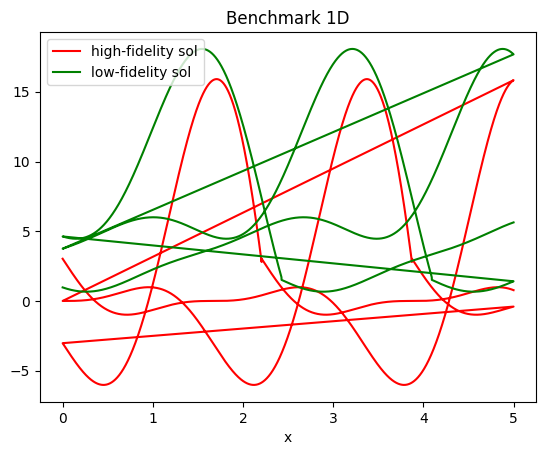

In [5]:
#%% Plot functions
plt.figure()
plt.plot(datatest[:,0],modified_highfid(datatest[:,0],datatest[:,1]),'r', label = 'high-fidelity sol')
plt.plot(datatest[:,0],modified_lowfid(datatest[:,0],datatest[:,1]),'g', label = 'low-fidelity sol')
#plt.plot(datahf[:,0],highfid(datahf[:,0],datahf[:,1]),'ro', label = 'high-fidelity data', markersize = 4)
#plt.plot(datalf[:,0],lowfid(datalf[:,0],datalf[:,1]),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model




The function training took 14.680206537246704 seconds.


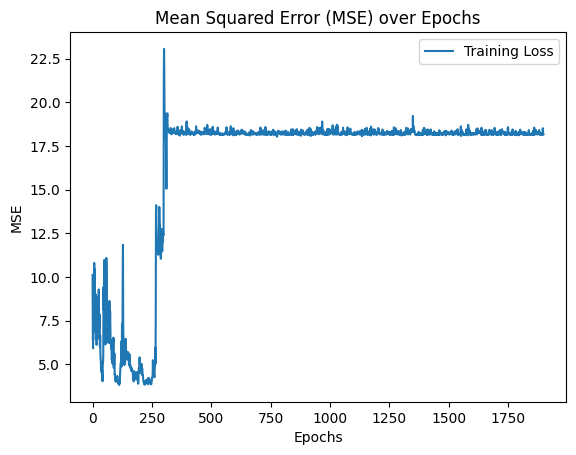

(30000, 2)
(30000,)
(30000, 1)
Test MSE: 67.1667862160811
R^2: -68539.45823617422


In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=datalf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(datatest)
(mse_LF,R2_LF)=modelLF.performance(datatest,modified_highfid(datatest[:,0],datatest[:,1]))

## High fidelity model

The function training took 15.678040266036987 seconds.


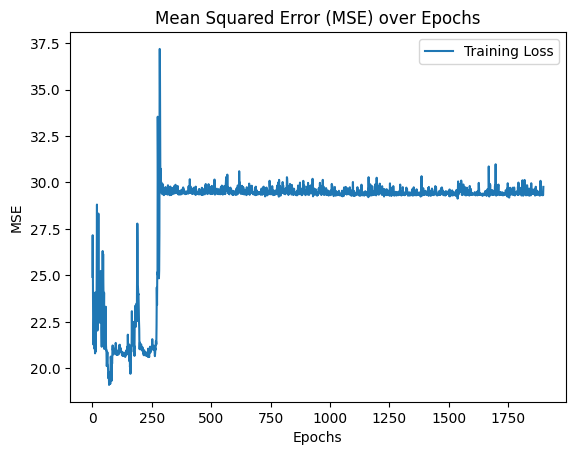

(30000, 2)
(30000,)
(30000, 1)
Test MSE: 30.215452941517658
R^2: -30832.408997159124


In [7]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=datahf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(datatest)
(mse_HF,R2_HF)=modelHF.performance(datatest,modified_highfid(datatest[:,0],datatest[:,1]))

## 2 Step model

The function training took 15.928673505783081 seconds.


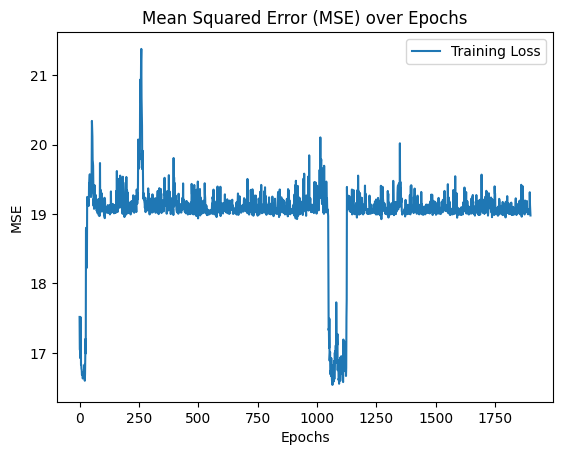

The function training took 11.854708909988403 seconds.


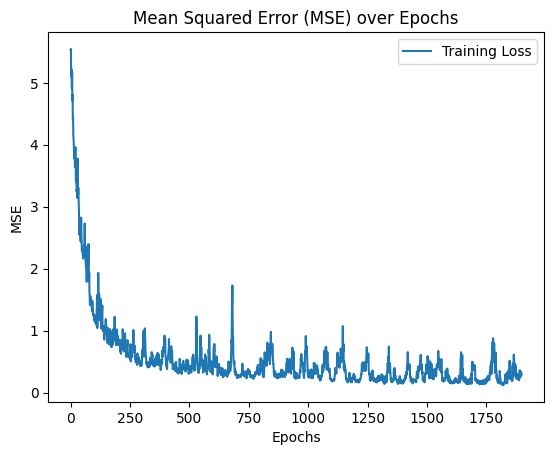

(30000, 3)
(30000,)
(30000, 1)
Test MSE: 58.52297993964489
R^2: -59718.87180546881


In [8]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[datalf,datahf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(datatest)

input_HF = np.concatenate(
                    (datatest,  final_model.model_list[0].prediction(datatest).reshape(-1,1)),axis=1
                ) 
(mse_MF,R2_MF)=final_model.model_list[1].performance(input_HF,modified_highfid(datatest[:,0],datatest[:,1]))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

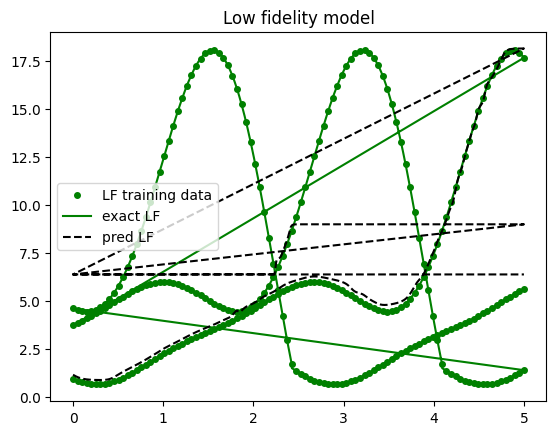

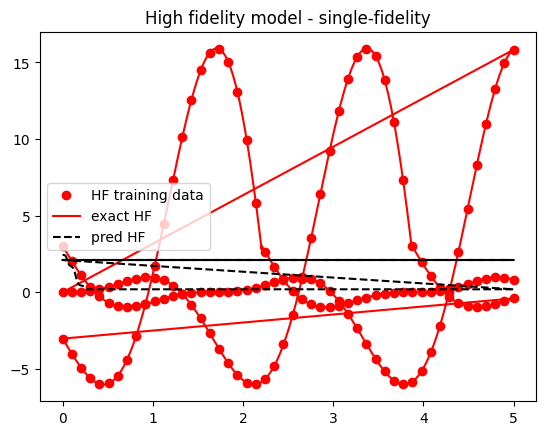

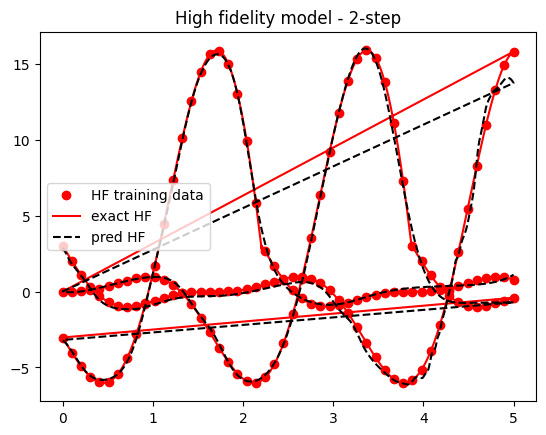

In [9]:
#LF
plt.figure()
plt.plot(datalf[:,0],Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(datatest[:,0],modified_lowfid(datatest[:,0],datatest[:,1]),'g', label = 'exact LF') 
plt.plot(datatest[:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(datahf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(datatest[:,0],modified_highfid(datatest[:,0],datatest[:,1]),'-r', label = 'exact HF')
plt.plot(datatest[:,0],yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(datahf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(datatest[:,0],modified_highfid(datatest[:,0],datatest[:,1]),'-r', label = 'exact HF')
plt.plot(datatest[:,0],y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# Inverse problem

noise 0.1
nb.data 30


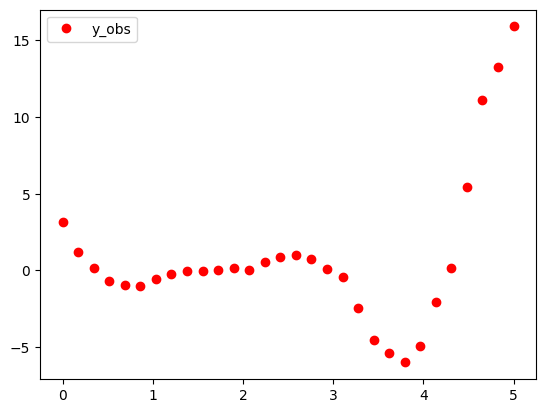

real values are [10.]
Sampling chain 1/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [07:23<00:00,  6.76it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [11:37<00:00,  4.30it/s]  
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [8.082]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.082  0.109   7.912    8.336      0.007    0.005     298.0     230.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.918]



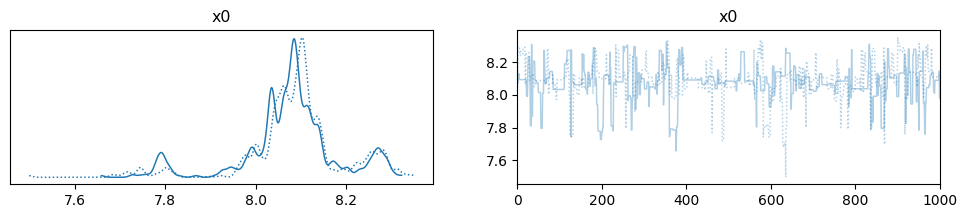

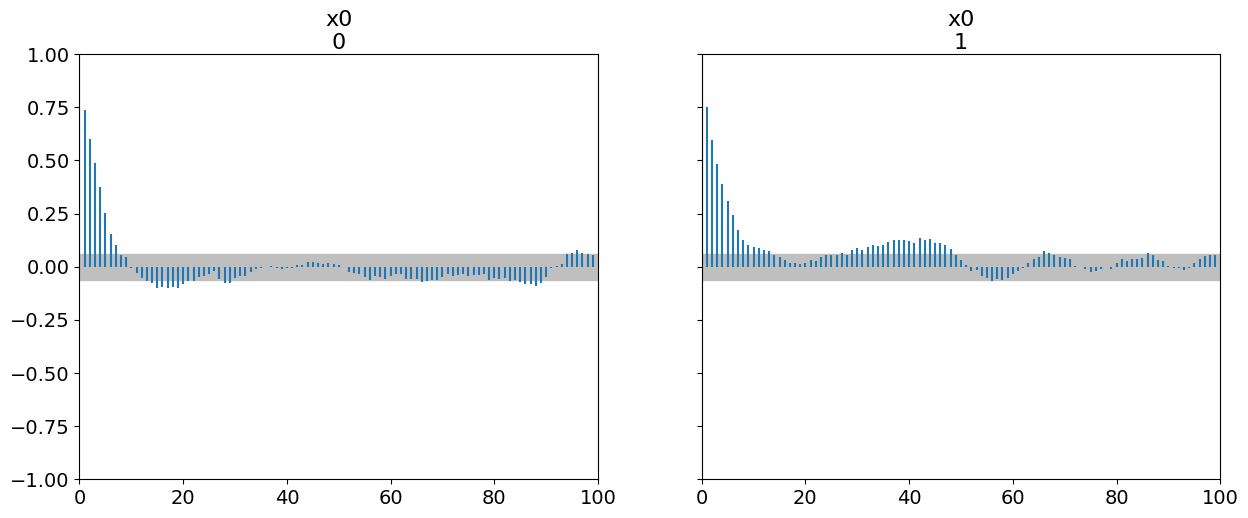

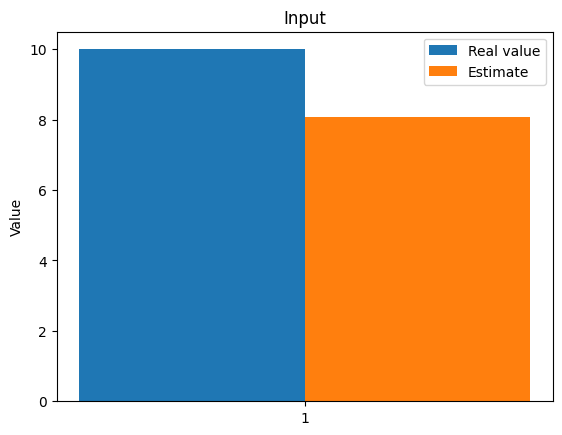

The function param_inverse took 1145.221913099289 seconds.
noise 0.1
nb.data 30


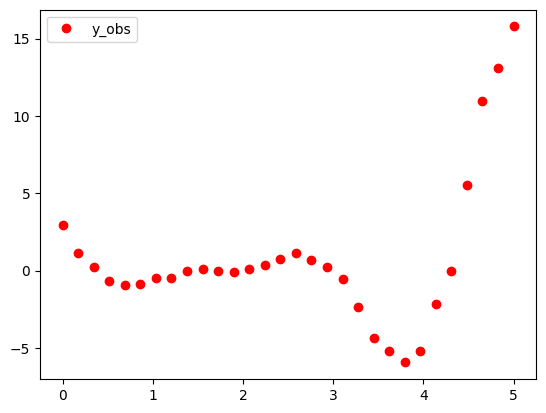

real values are [10.]
Sampling chain 1/2


Running chain, α = 0.14:   5%|▍         | 146/3000 [00:24<08:06,  5.86it/s]


KeyboardInterrupt: 

In [10]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([10.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([7.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,1.,2.])
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")



noise 0.1
nb.data 30


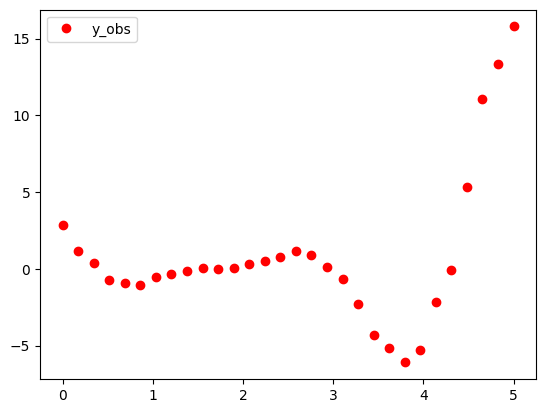

real values are [10.]
Sampling chain 1/3


Running chain, α = 0.20: 100%|██████████| 4000/4000 [06:40<00:00,  9.99it/s]


Sampling chain 2/3


Running chain, α = 0.24: 100%|██████████| 4000/4000 [07:46<00:00,  8.57it/s]


Sampling chain 3/3


Running chain, α = 0.25: 100%|██████████| 4000/4000 [09:54<00:00,  6.73it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [8.079]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.079  0.017   8.049    8.111      0.001    0.001     454.0     457.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.921]



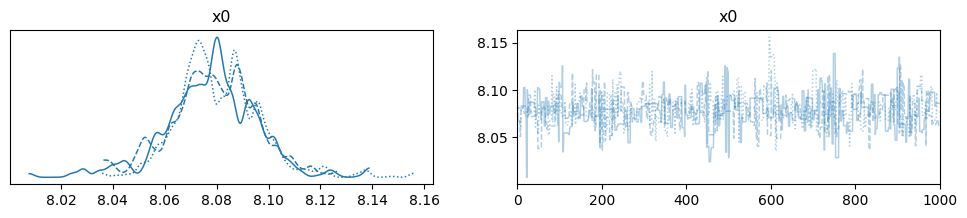

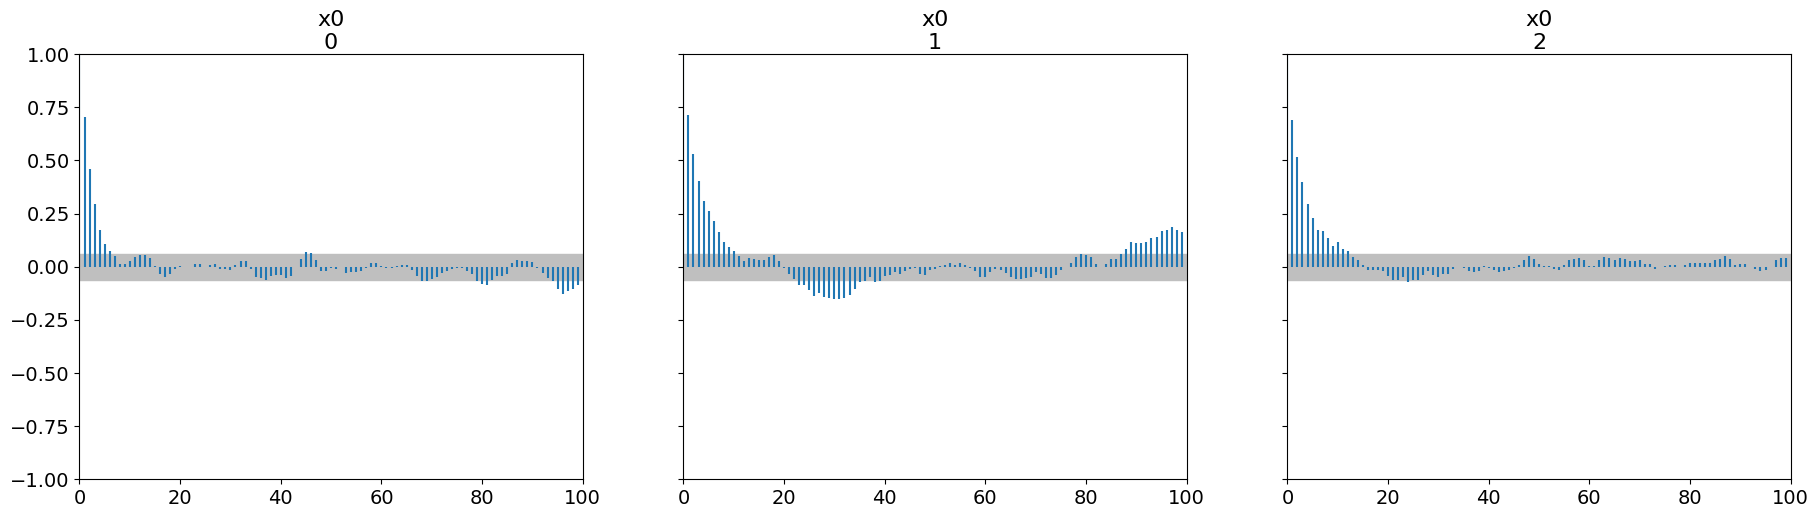

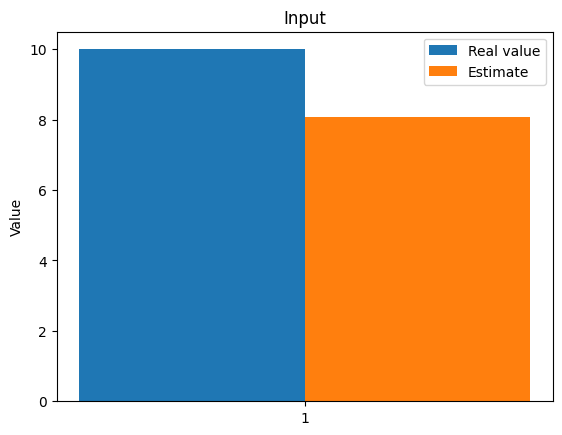

The function param_inverse took 1461.8462409973145 seconds.
noise 0.1
nb.data 30


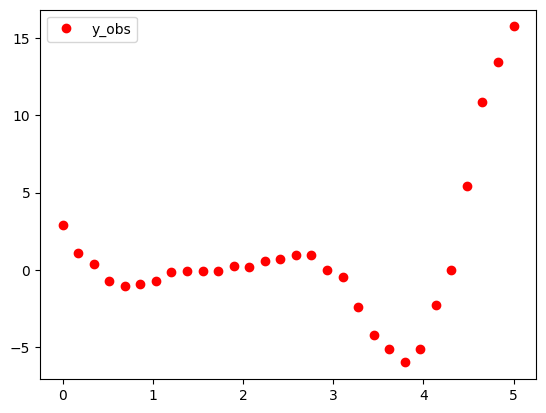

real values are [10.]
Sampling chain 1/3


Running chain, α = 0.04:  16%|█▌        | 645/4000 [01:09<06:00,  9.31it/s]


KeyboardInterrupt: 

In [13]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([10.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([1.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,1.,2.])
rwmh_adaptive = True
iterations =4000
burnin = 3000
n_chains=3

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")



rwh 1 sembra no portare da nessuna parte (acc. rate basso)

noise 0.1
nb.data 30
rwmh.scaling 0.25


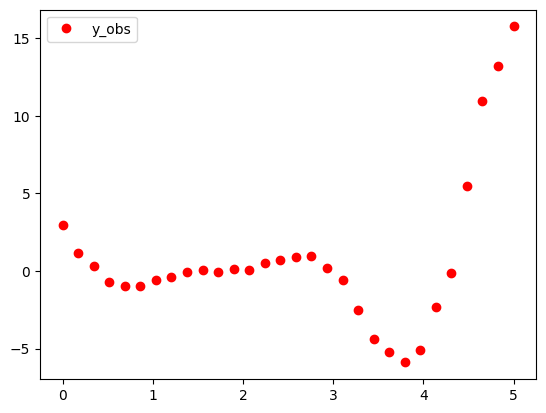

real values are [10.]
Sampling chain 1/3


Running chain, α = 0.25: 100%|██████████| 4000/4000 [11:41<00:00,  5.70it/s]


Sampling chain 2/3


Running chain, α = 0.19: 100%|██████████| 4000/4000 [12:08<00:00,  5.49it/s]


Sampling chain 3/3


Running chain, α = 0.28: 100%|██████████| 4000/4000 [07:24<00:00,  8.99it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [8.08]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.08  0.018   8.047    8.113      0.001    0.001     442.0     453.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [1.92]



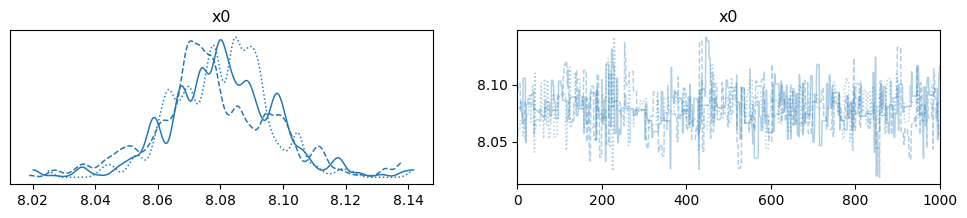

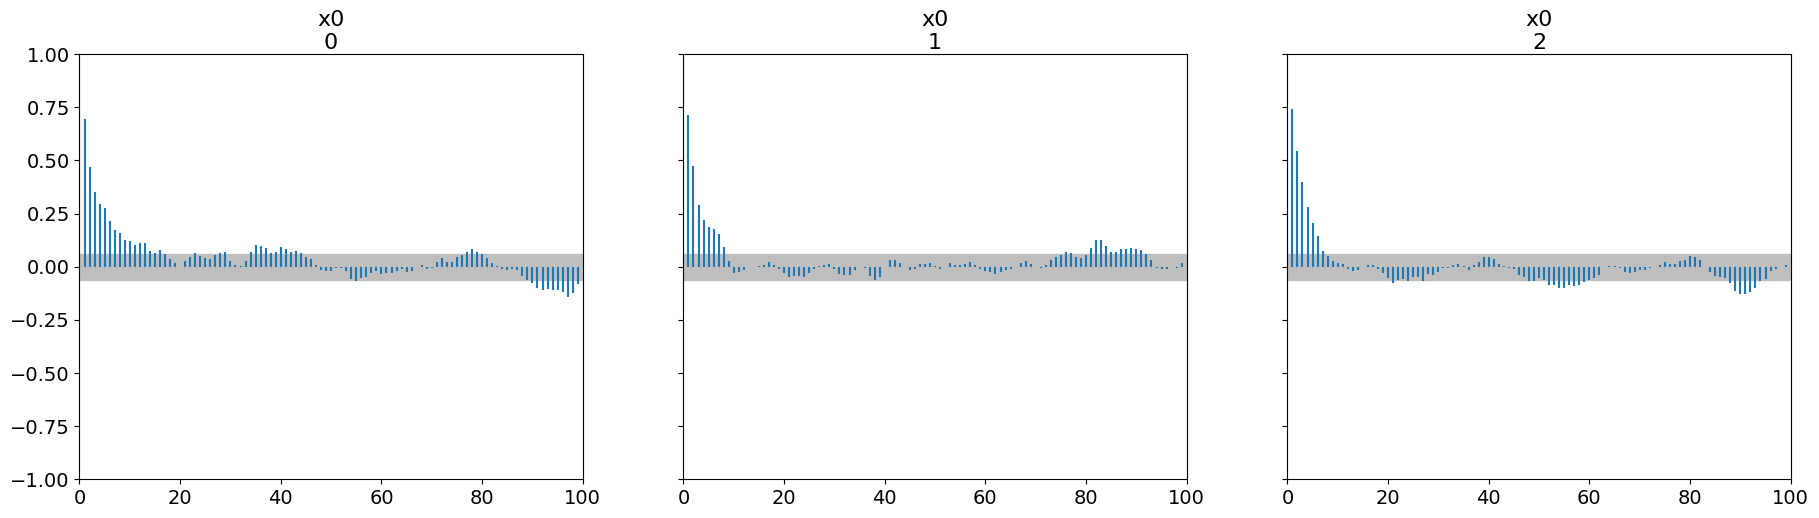

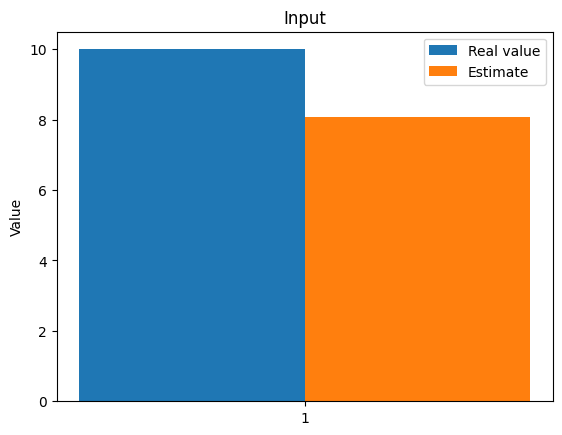

The function param_inverse took 1875.603515625 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.25


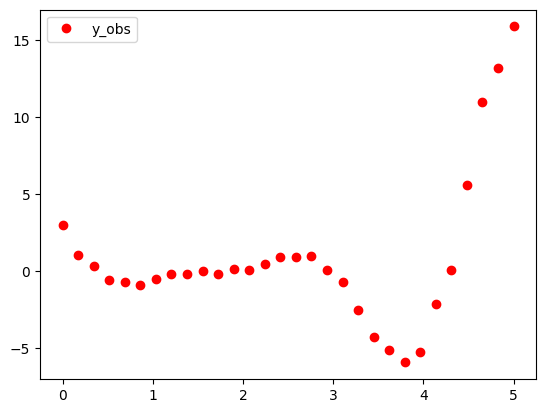

real values are [10.]
Sampling chain 1/3


Running chain, α = 0.31: 100%|██████████| 4000/4000 [06:35<00:00, 10.11it/s]


Sampling chain 2/3


Running chain, α = 0.25: 100%|██████████| 4000/4000 [06:33<00:00, 10.16it/s]


Sampling chain 3/3


Running chain, α = 0.22: 100%|██████████| 4000/4000 [07:26<00:00,  8.96it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [8.079]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.079  0.016   8.052    8.111      0.001    0.001     430.0     517.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.921]



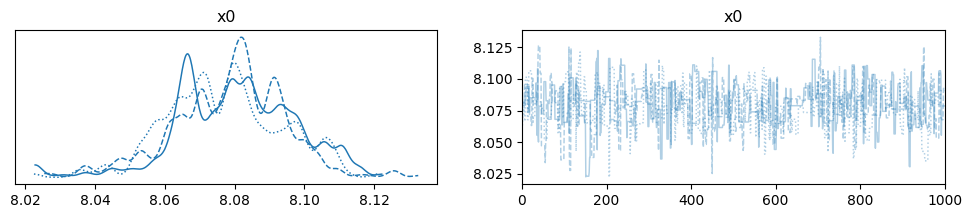

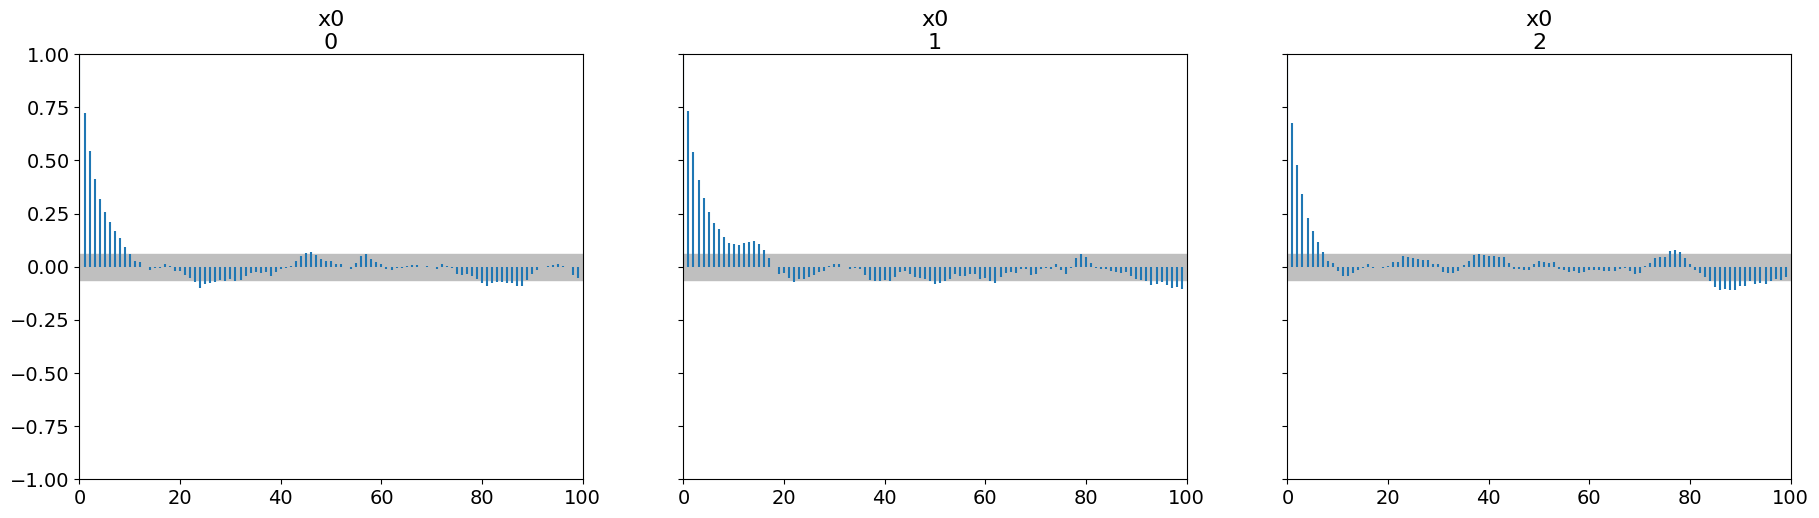

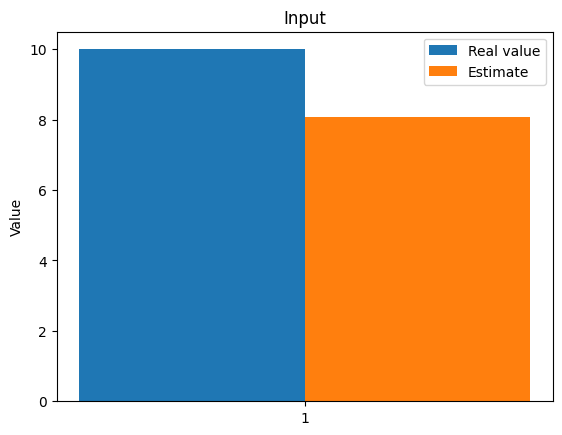

The function param_inverse took 1236.7870886325836 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


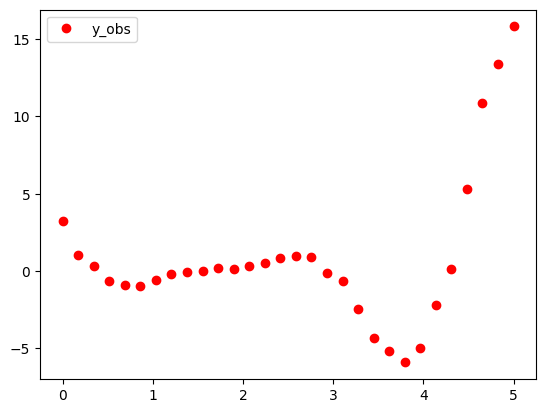

real values are [10.]
Sampling chain 1/3


Running chain, α = 0.33:   4%|▍         | 157/4000 [00:17<07:08,  8.97it/s]


KeyboardInterrupt: 

In [14]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([10.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([1.,2.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.25,0.1])
rwmh_adaptive = True
iterations =4000
burnin = 3000
n_chains=3

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


In [17]:
parameters=np.array([0.])
indices = np.where(datahf[:,1] == parameters)[0]
print(indices)

parameters=np.array([10.])
indices = np.where(datahf[:,1] == parameters)[0]
print(indices)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
[50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]


In [25]:
print(indices)

[50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]


In [27]:
t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


closest_indices= np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#
print(indices[0]+closest_indices)

[50 52 53 55 57 58 60 62 64 65 67 69 70 72 74 75 77 79 80 82 84 85 87 89
 91 92 94 96 97 99]


noise 0.1
nb.data 30
rwmh.scaling 0.5


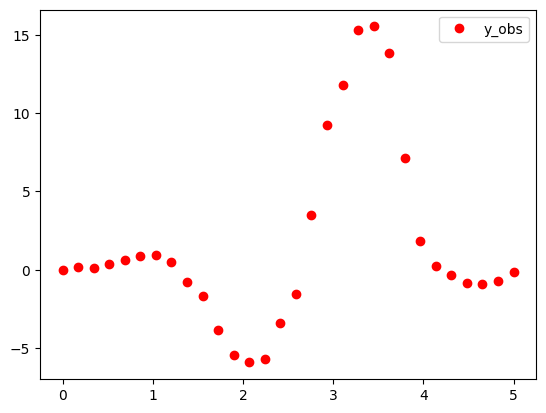

real values are [10.]
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 2000/2000 [03:36<00:00,  9.23it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [03:18<00:00, 10.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [9.986]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.986  0.153   9.713   10.273      0.008    0.006     362.0     387.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.014]



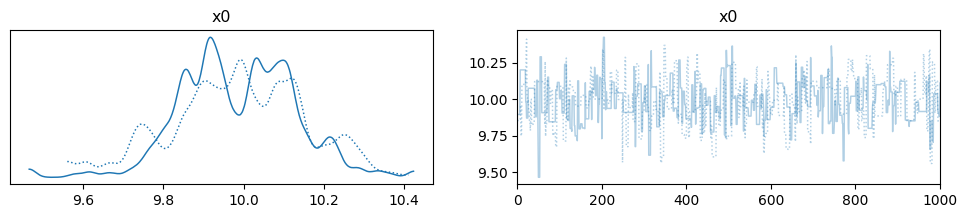

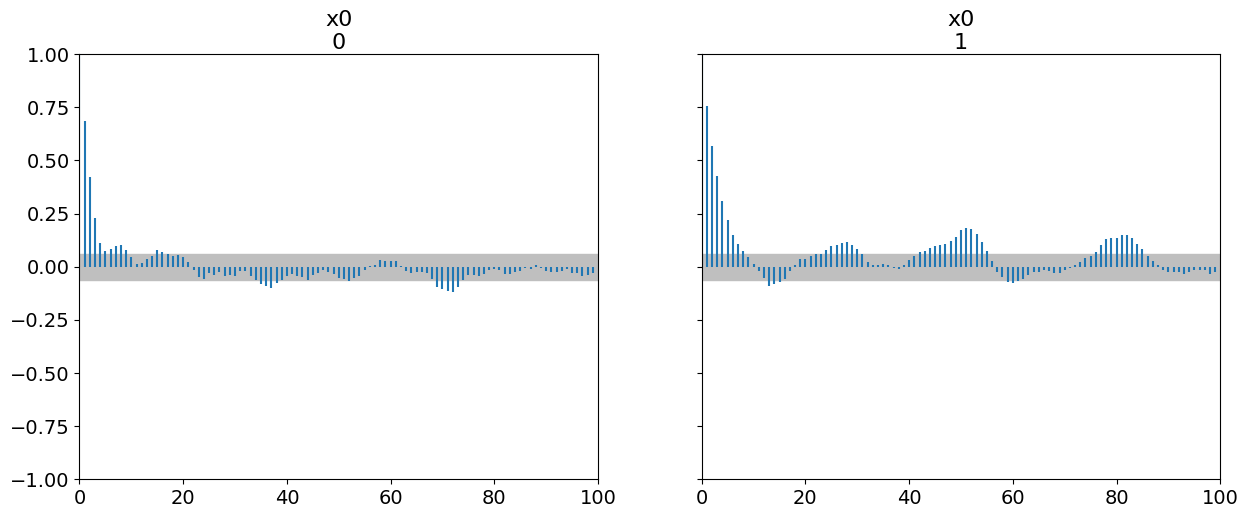

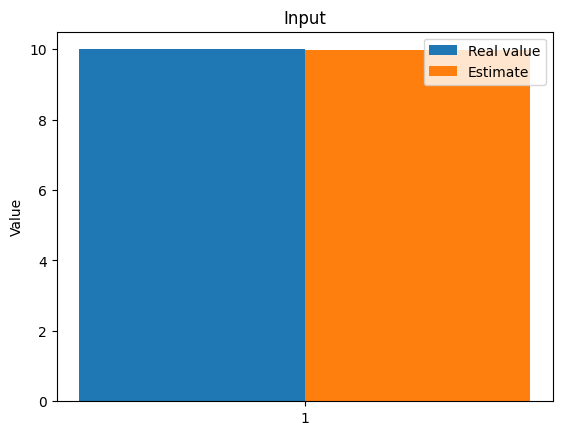

The function param_inverse took 415.898188829422 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5


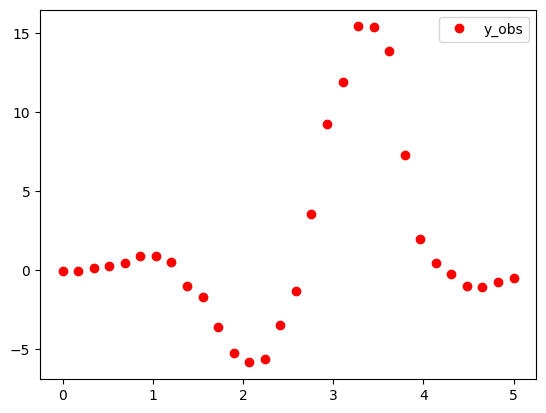

real values are [10.]
Sampling chain 1/2


Running chain, α = 0.05:  46%|████▌     | 915/2000 [01:32<01:50,  9.86it/s]


KeyboardInterrupt: 

In [31]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([10.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


noise 0.1
nb.data 30
rwmh.scaling 1.0


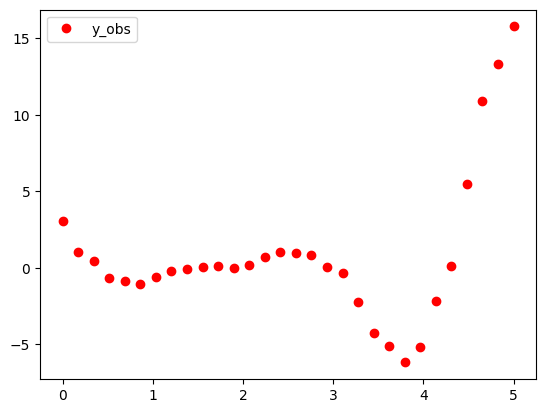

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [03:17<00:00, 10.10it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [03:19<00:00, 10.05it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.071]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.071  0.098  -0.125    0.244      0.006    0.004     283.0     199.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.071]



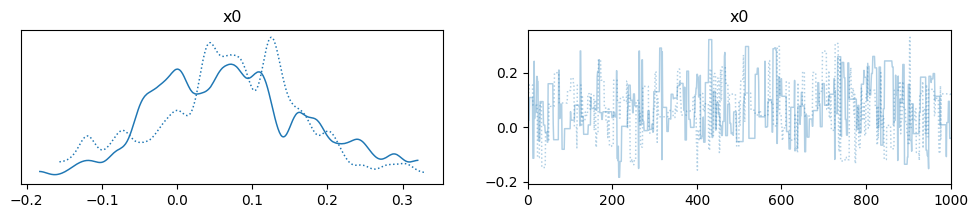

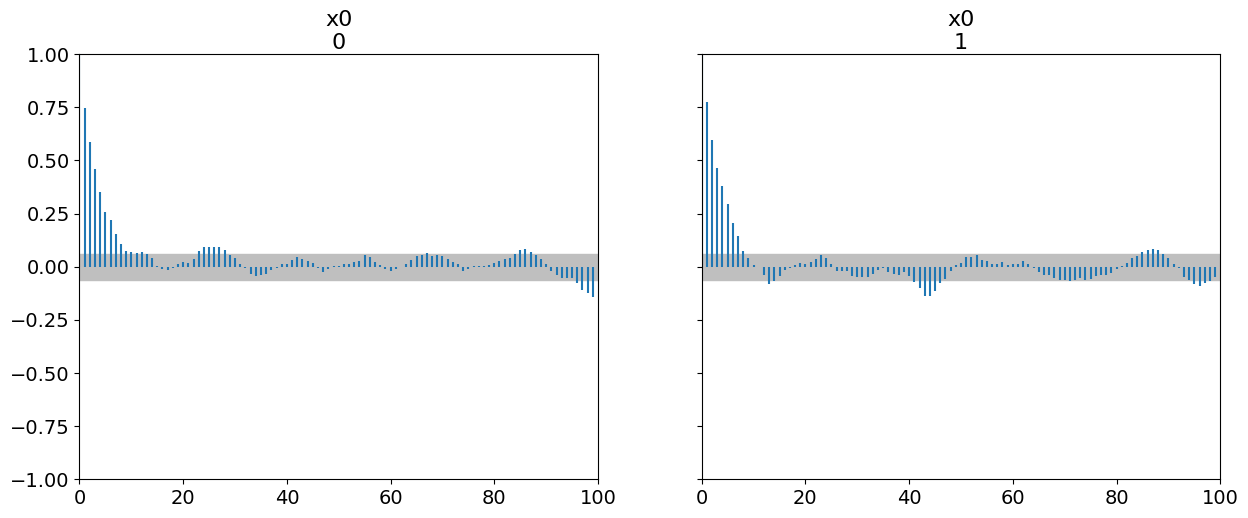

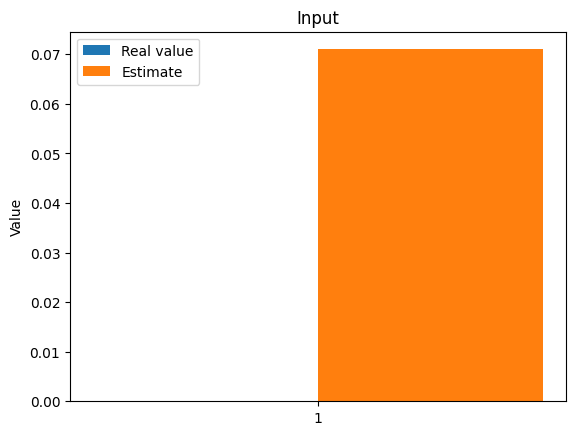

The function param_inverse took 398.25877499580383 seconds.
noise 0.1
nb.data 30
rwmh.scaling 1.0


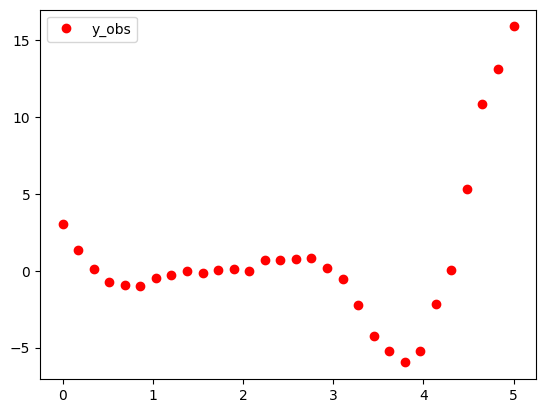

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.37: 100%|██████████| 2000/2000 [03:18<00:00, 10.09it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 2000/2000 [03:18<00:00, 10.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [4.976]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  4.976  3.084   1.889    8.135      2.172    1.837       3.0      56.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [4.976]



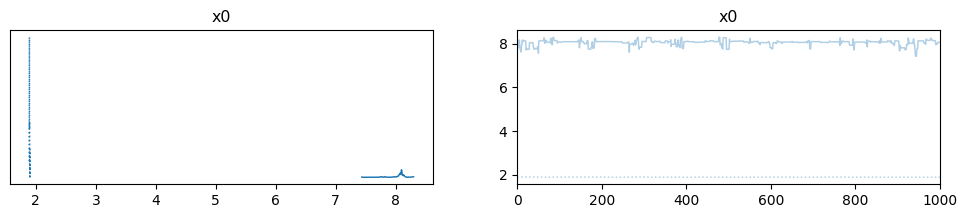

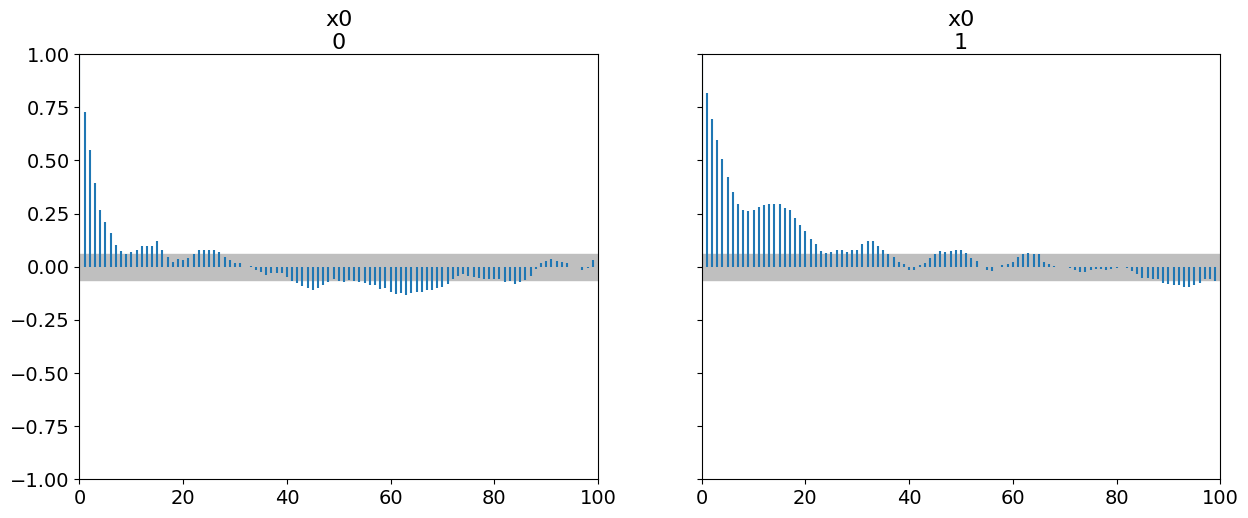

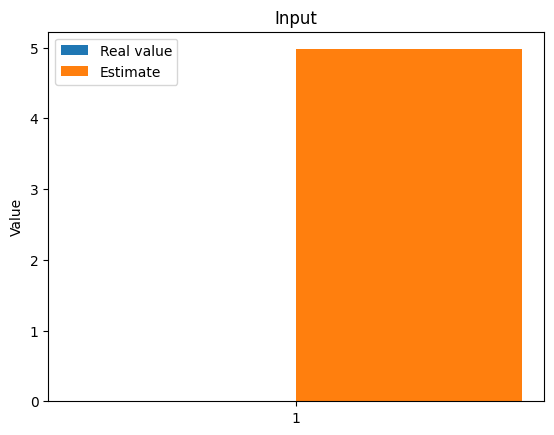

The function param_inverse took 397.485390663147 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


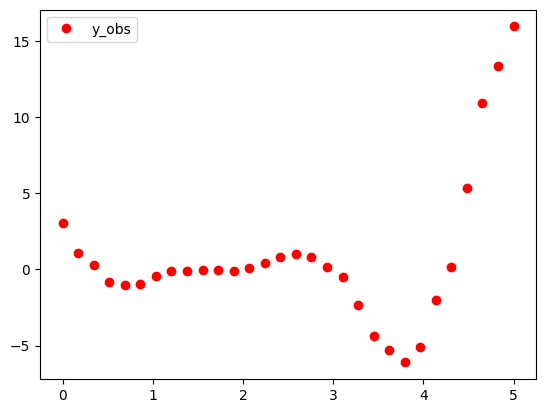

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [03:18<00:00, 10.06it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 2000/2000 [03:18<00:00, 10.05it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.127]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.127  0.13  -0.108    0.337       0.01    0.007     186.0     270.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [0.127]



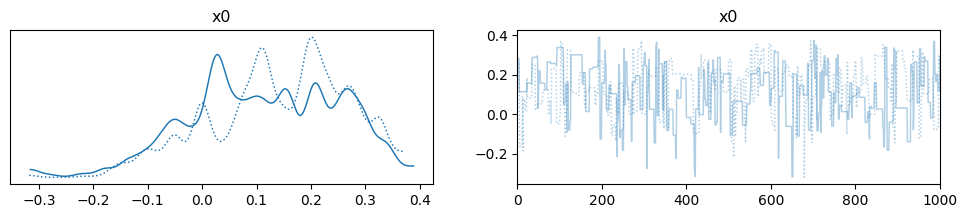

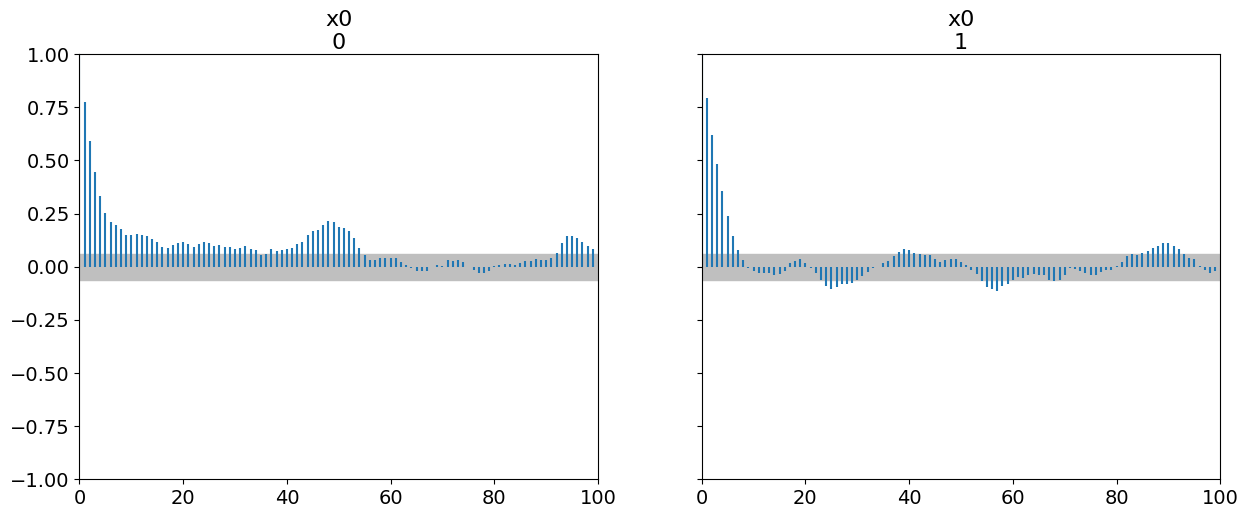

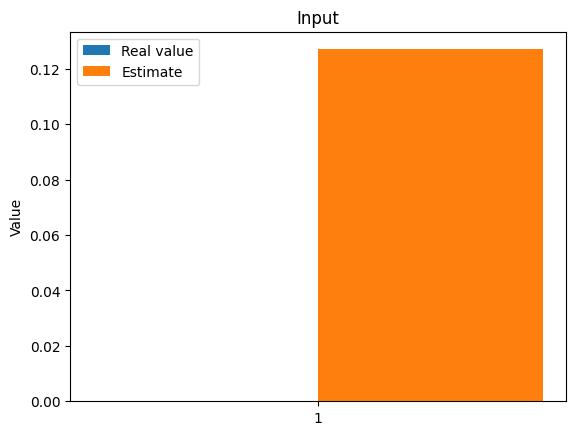

The function param_inverse took 398.73182940483093 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


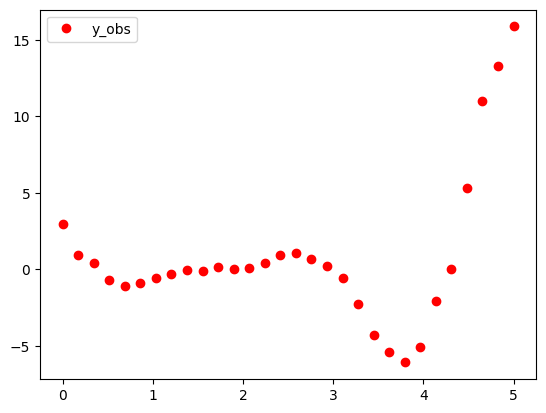

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 2000/2000 [03:18<00:00, 10.06it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [03:18<00:00, 10.06it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.147]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.147  0.132  -0.112    0.349      0.013    0.009     102.0      96.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [0.147]



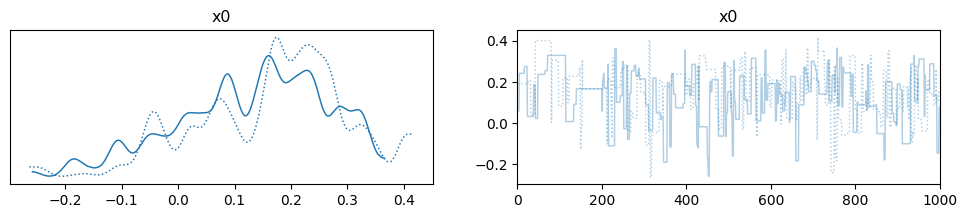

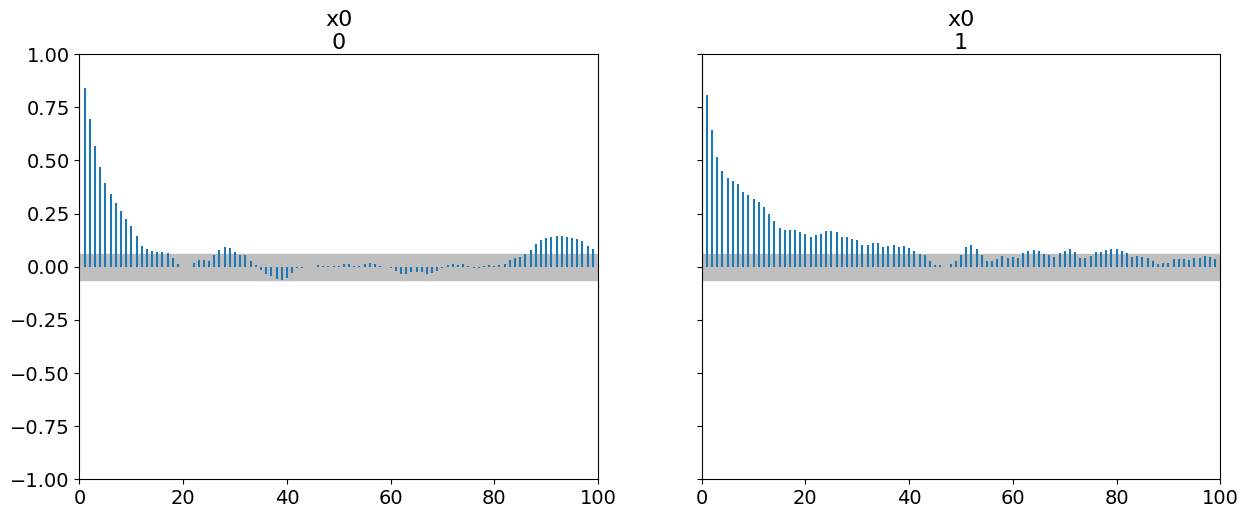

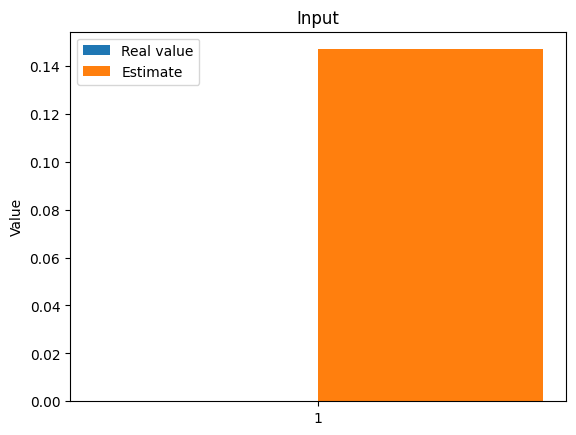

The function param_inverse took 398.4328398704529 seconds.
noise 0.1
nb.data 50
rwmh.scaling 1.0


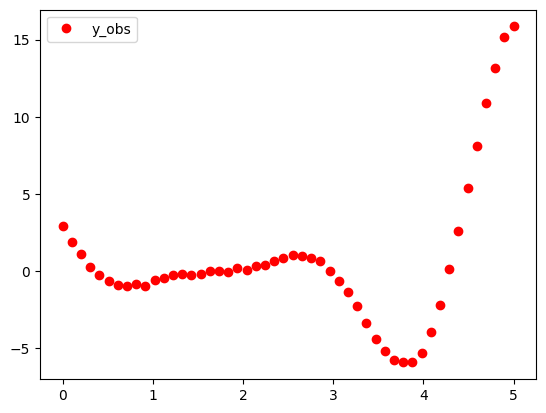

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 2000/2000 [03:29<00:00,  9.56it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 2000/2000 [03:29<00:00,  9.55it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [8.048]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  8.048  0.08   7.878    8.128      0.005    0.004     255.0     339.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.048]



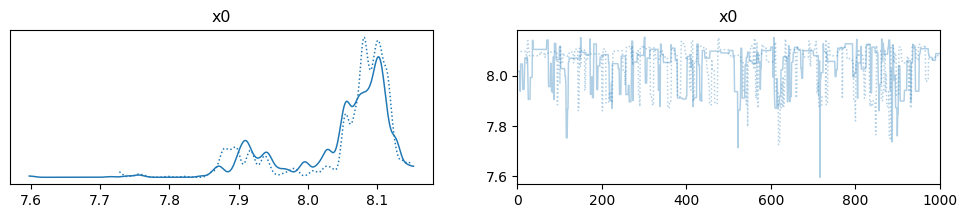

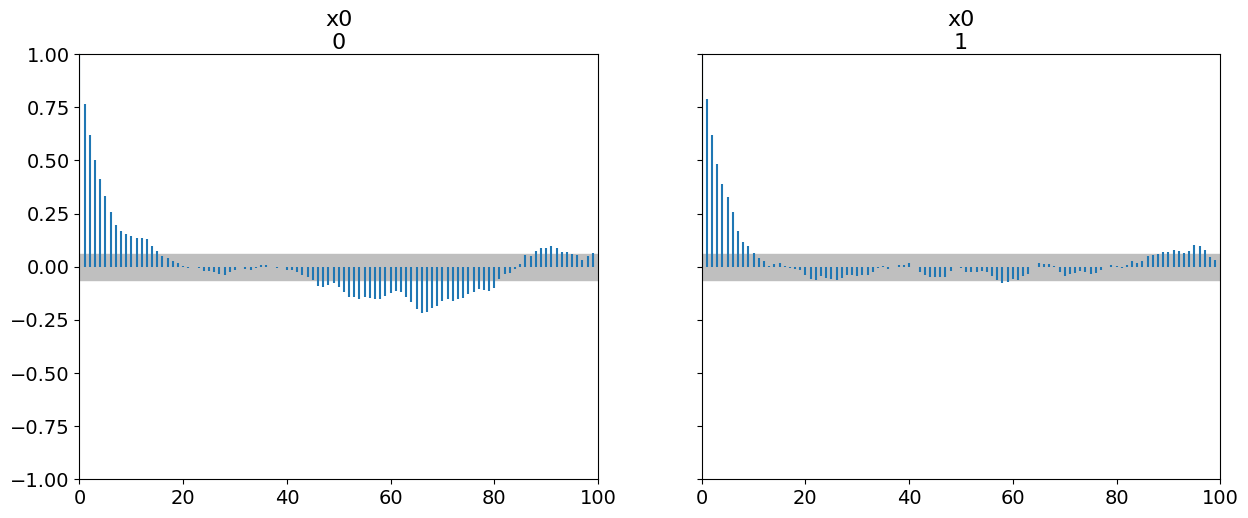

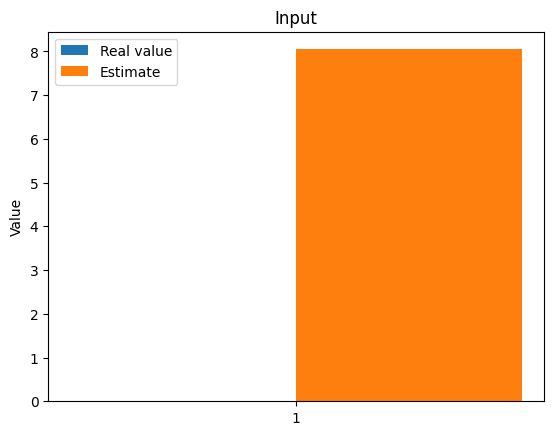

The function param_inverse took 419.40260076522827 seconds.
noise 0.1
nb.data 50
rwmh.scaling 1.0


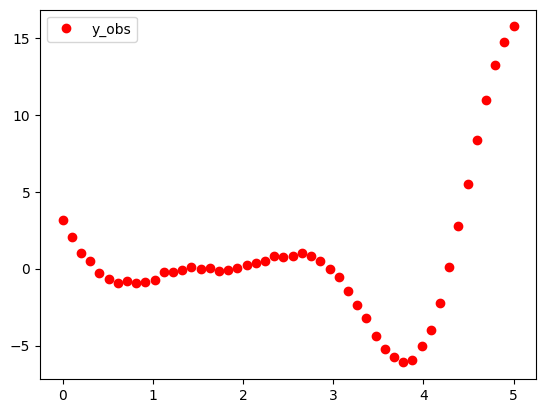

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.14: 100%|██████████| 2000/2000 [03:29<00:00,  9.56it/s]


Sampling chain 2/2


Running chain, α = 0.18: 100%|██████████| 2000/2000 [03:29<00:00,  9.56it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [4.97]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  4.97  3.079    1.89    8.114      2.168    1.834       3.0      97.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [4.97]



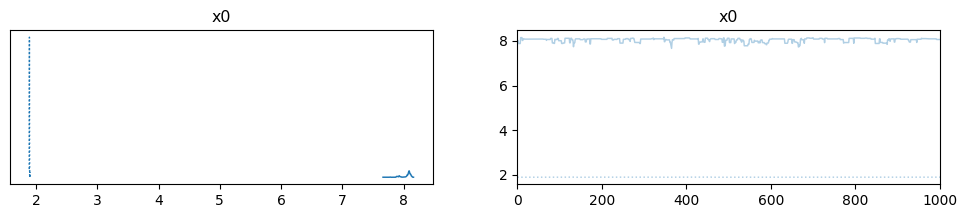

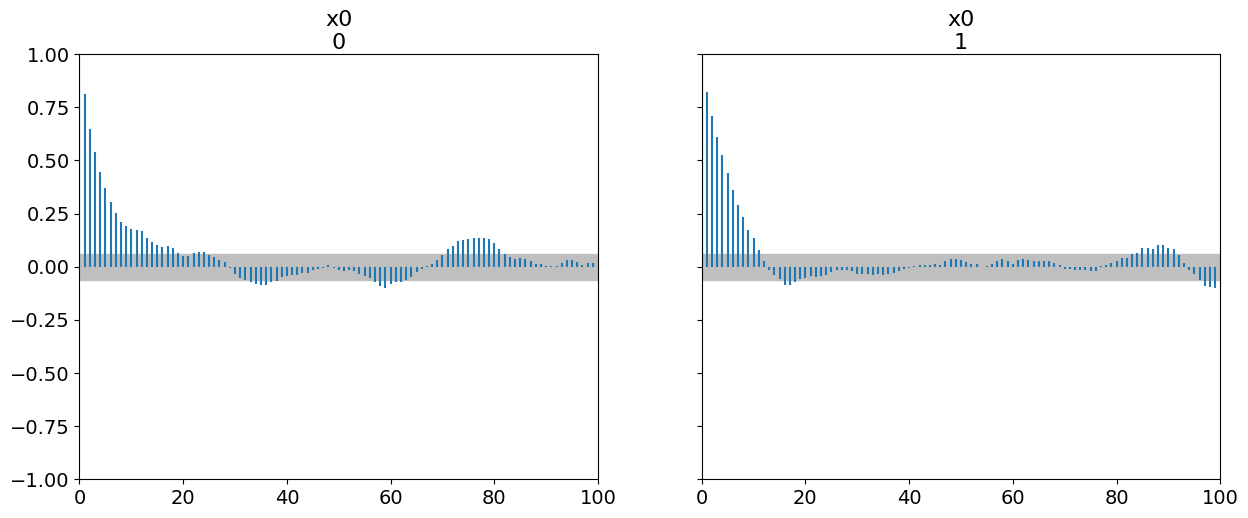

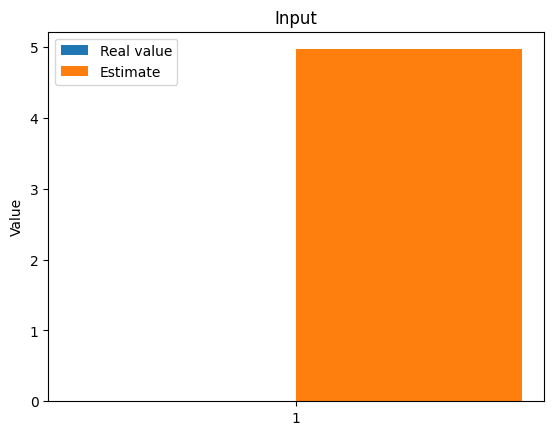

The function param_inverse took 419.3102090358734 seconds.
noise 0.1
nb.data 50
rwmh.scaling 0.1


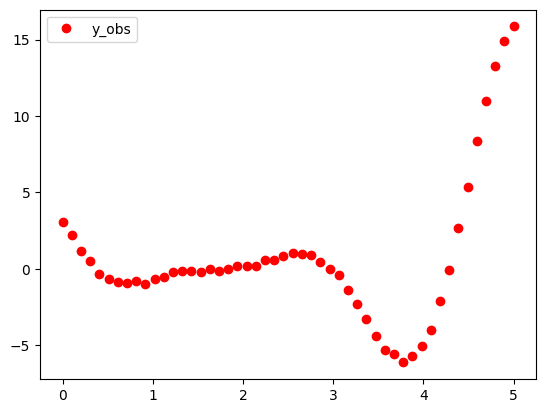

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.13: 100%|██████████| 2000/2000 [03:30<00:00,  9.52it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 2000/2000 [03:29<00:00,  9.55it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.086]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.086  0.135  -0.148    0.325      0.012    0.008     148.0     242.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.086]



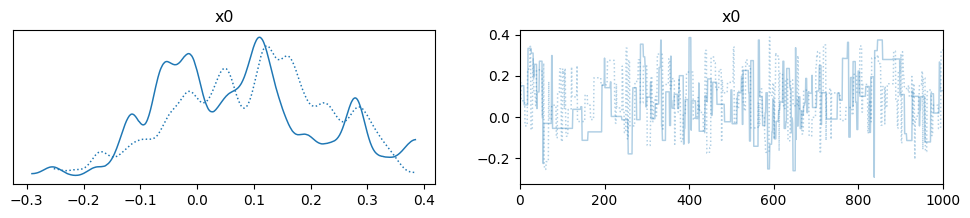

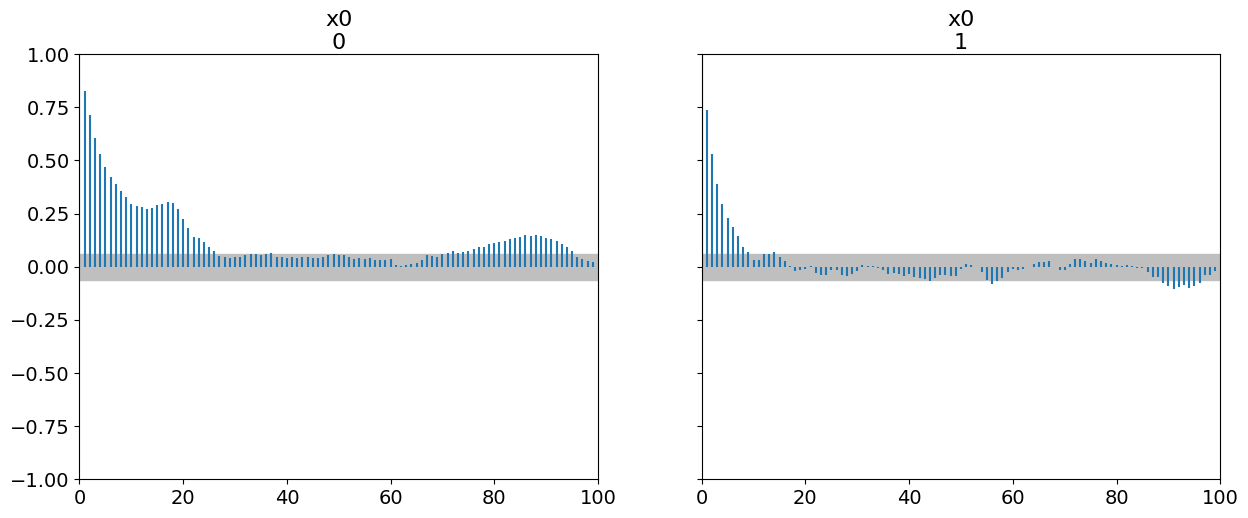

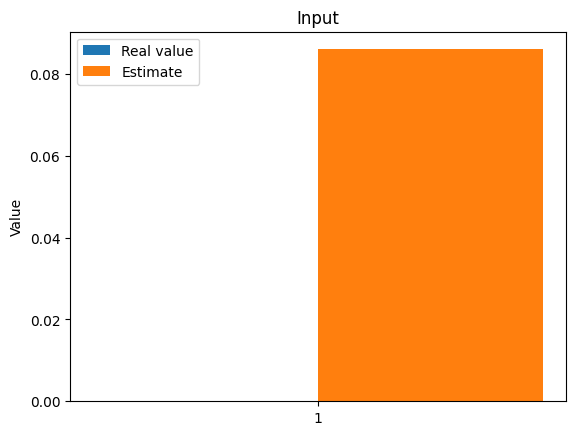

The function param_inverse took 420.37194418907166 seconds.
noise 0.1
nb.data 50
rwmh.scaling 0.1


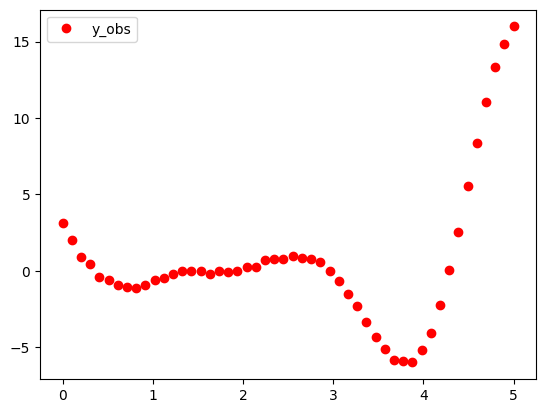

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.14: 100%|██████████| 2000/2000 [03:29<00:00,  9.55it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [03:33<00:00,  9.39it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.002]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.002  0.898  -0.079    1.929      0.629    0.535       3.0     109.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [1.002]



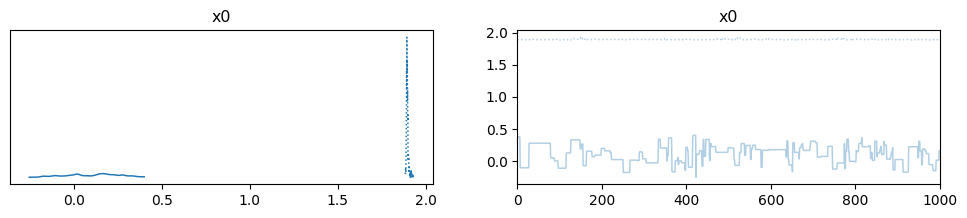

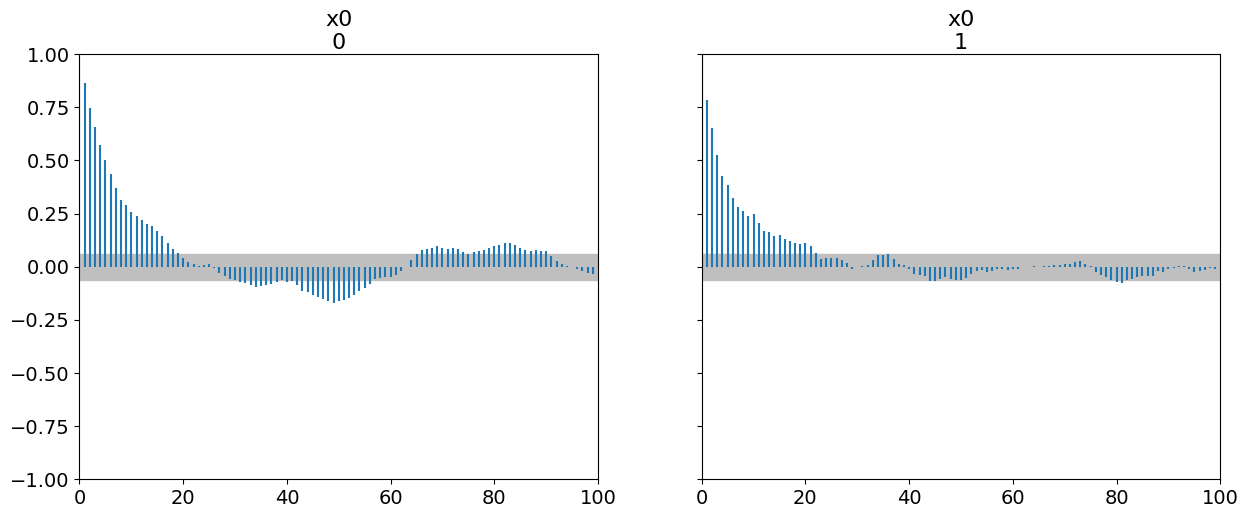

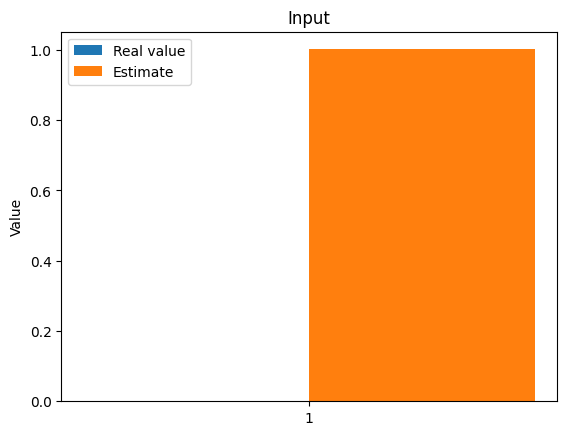

The function param_inverse took 423.2356550693512 seconds.


In [36]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([0.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([4.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([1.,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")

noise 0.1
nb.data 30
rwmh.scaling 1.0


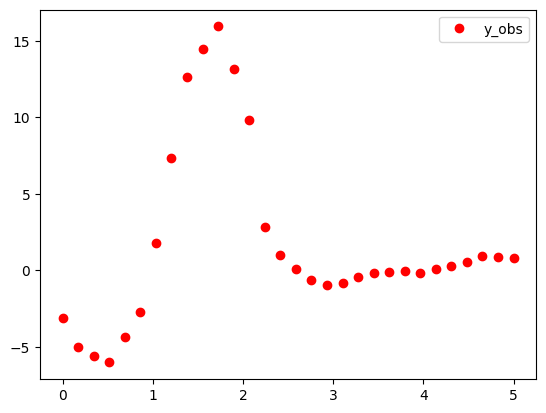

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [03:00<00:00, 11.09it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 2000/2000 [03:04<00:00, 10.85it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [18.894]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  18.894  0.286  18.401   19.407      0.016    0.011     338.0     191.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.106]



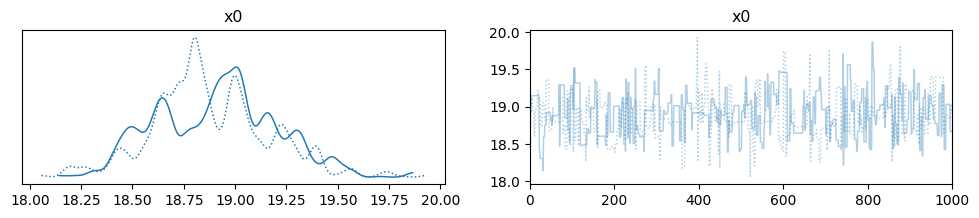

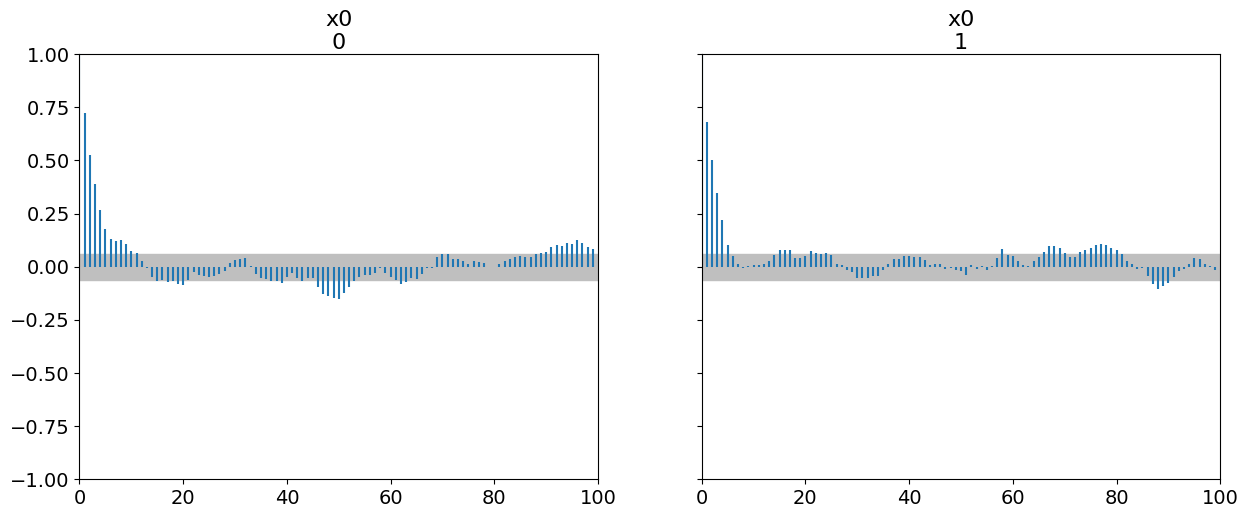

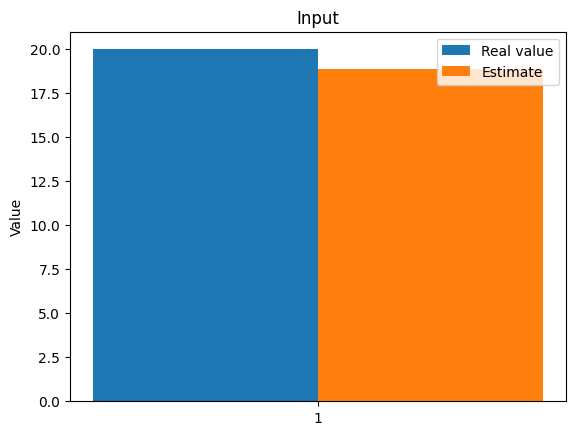

The function param_inverse took 365.5059976577759 seconds.
noise 0.1
nb.data 30
rwmh.scaling 1.0


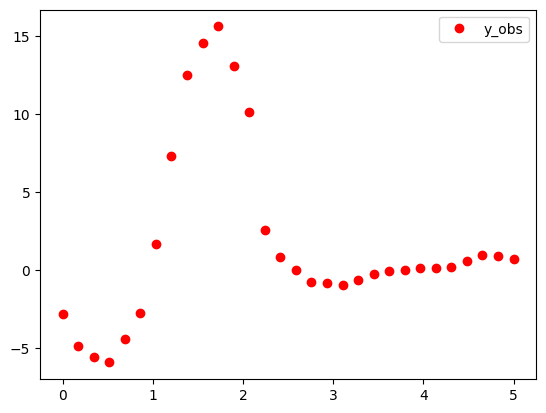

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.22: 100%|██████████| 2000/2000 [03:14<00:00, 10.26it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [05:36<00:00,  5.94it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [18.912]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  18.912  0.308  18.346   19.447      0.017    0.012     314.0     258.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.088]



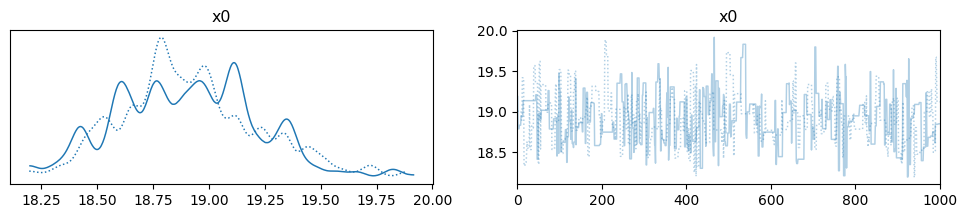

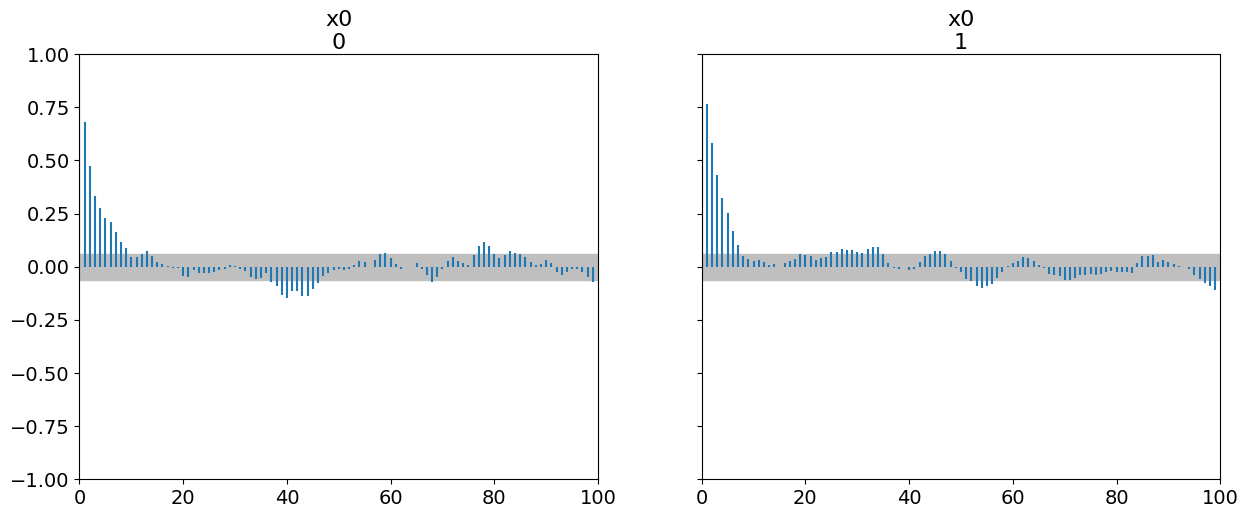

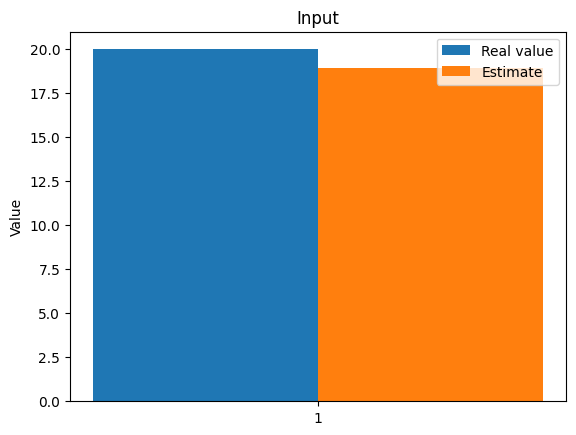

The function param_inverse took 533.1283178329468 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


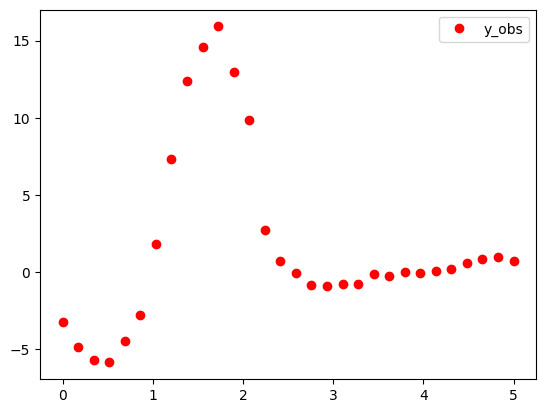

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [04:44<00:00,  7.02it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [03:54<00:00,  8.51it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [17.418]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  17.418  0.449  16.623   18.242      0.025    0.018     320.0     431.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [2.582]



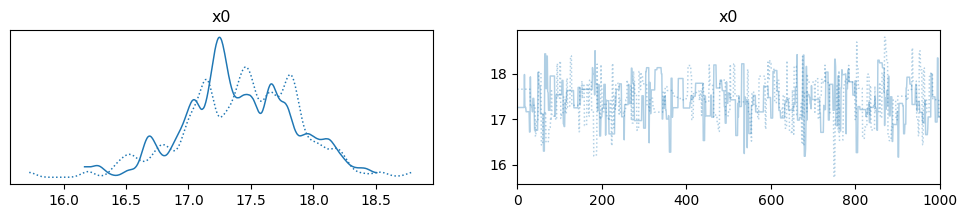

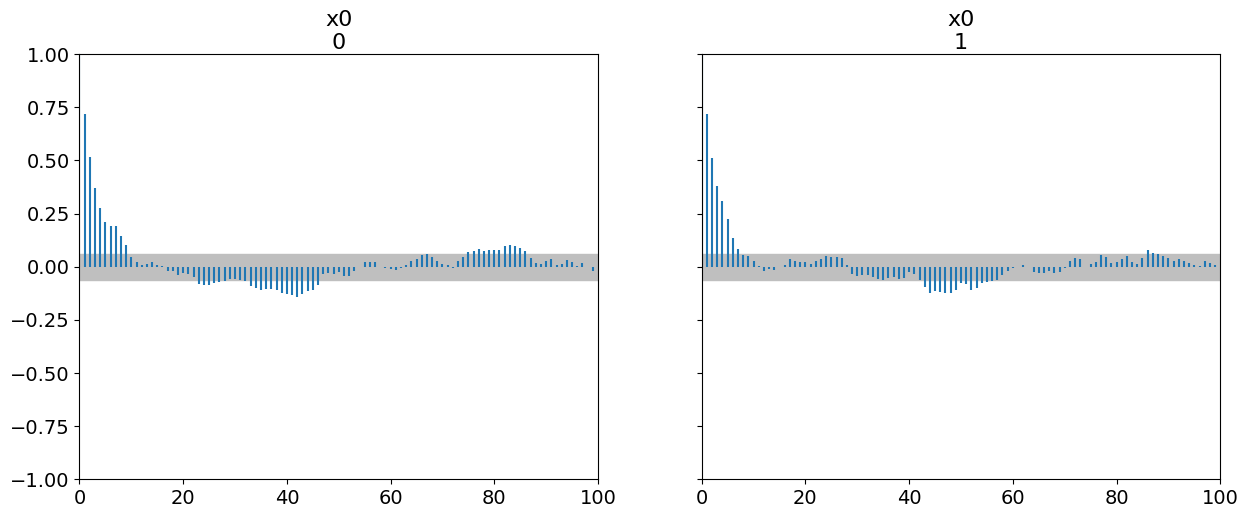

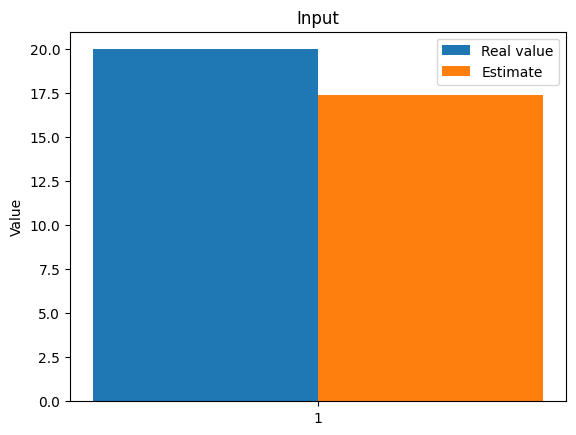

The function param_inverse took 521.2895510196686 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


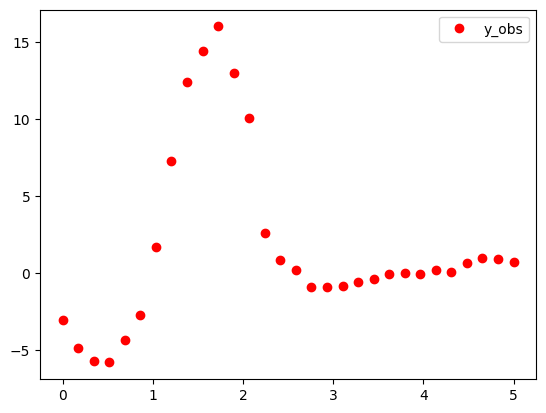

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.33: 100%|██████████| 2000/2000 [05:45<00:00,  5.80it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 2000/2000 [05:30<00:00,  6.05it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [17.393]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  17.393  0.467   16.53   18.158      0.023    0.016     418.0     367.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [2.607]



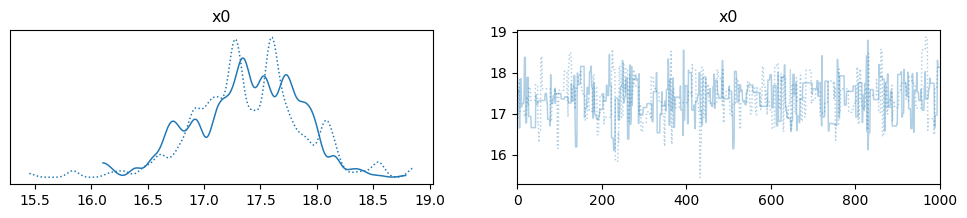

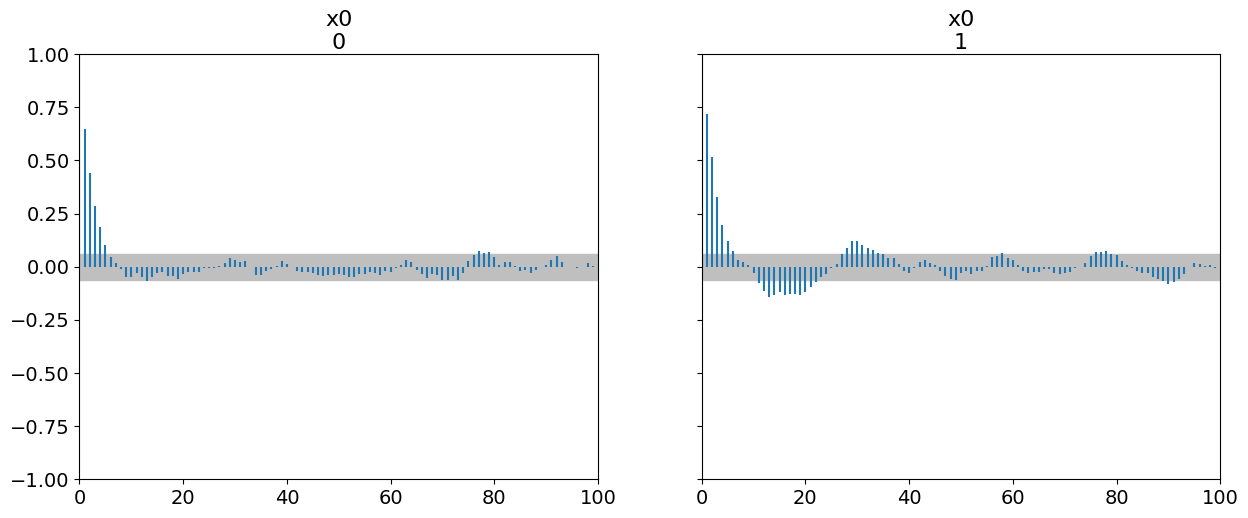

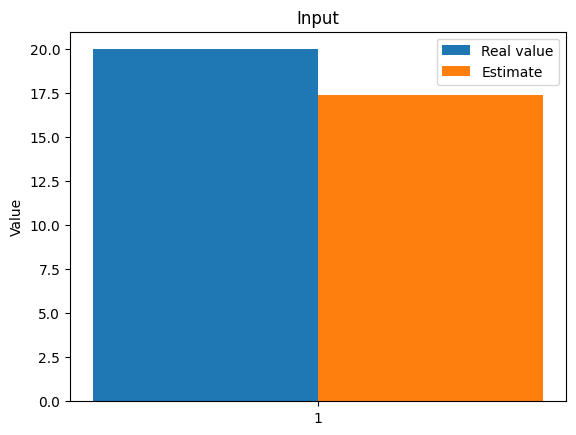

The function param_inverse took 677.073869228363 seconds.
noise 0.1
nb.data 50
rwmh.scaling 1.0


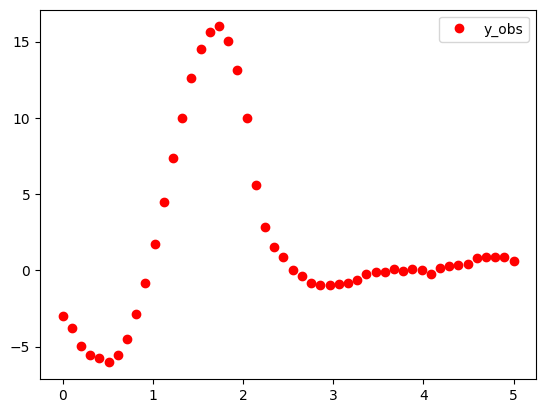

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [05:45<00:00,  5.79it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [05:37<00:00,  5.93it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [19.177]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  19.177  0.256  18.634   19.633      0.014     0.01     307.0     229.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.823]



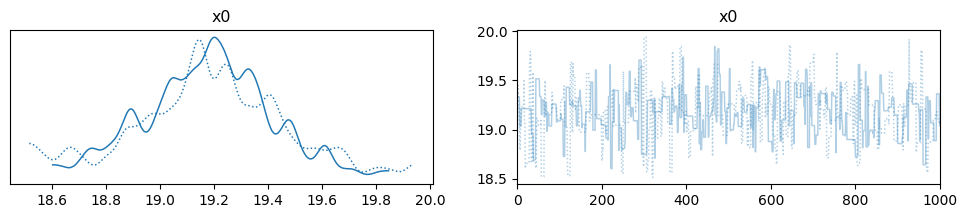

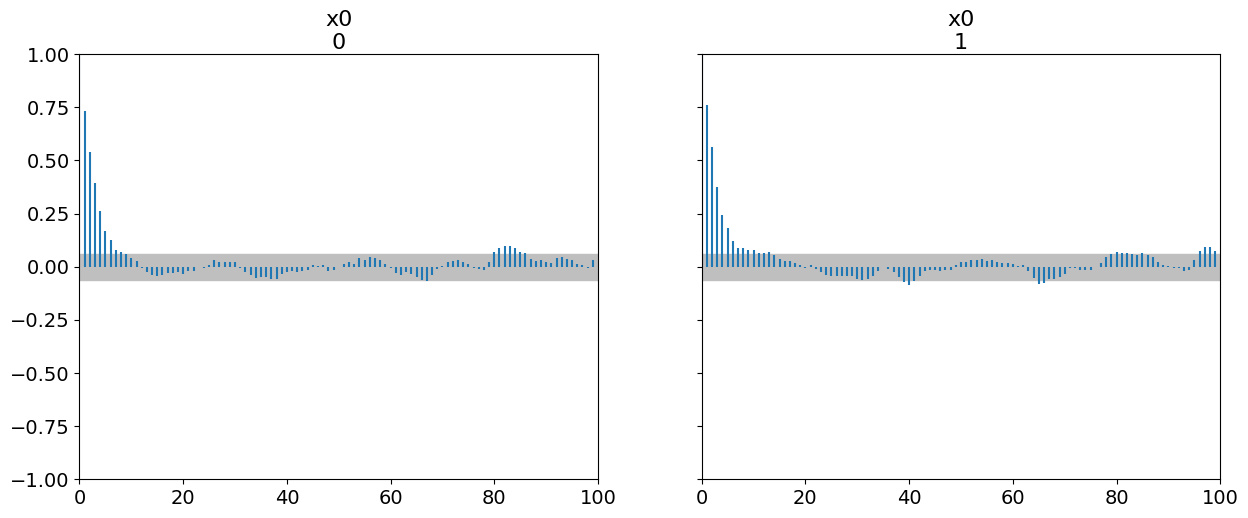

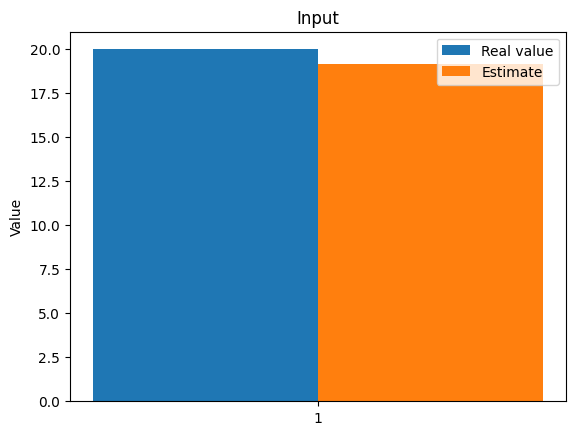

The function param_inverse took 683.5850133895874 seconds.
noise 0.1
nb.data 50
rwmh.scaling 1.0


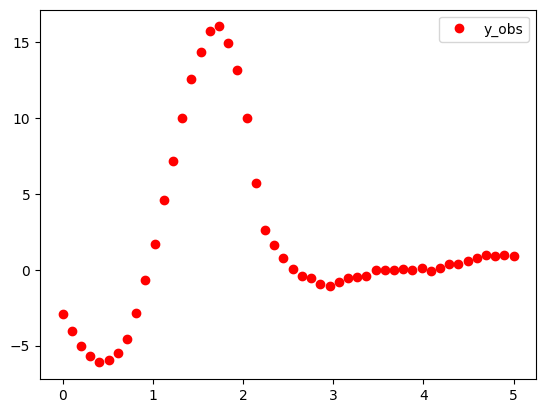

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.22: 100%|██████████| 2000/2000 [06:10<00:00,  5.40it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 2000/2000 [05:48<00:00,  5.73it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [11.894]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.894  7.251   4.478   19.478      5.105    4.318       3.0      71.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [8.106]



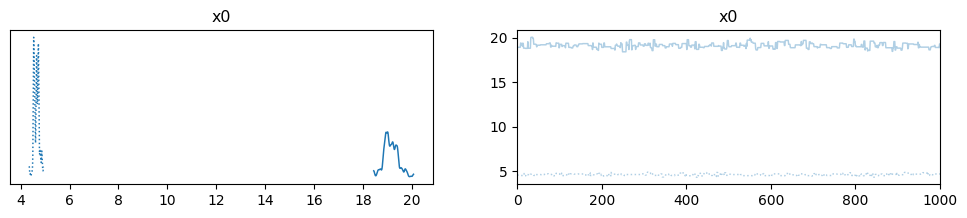

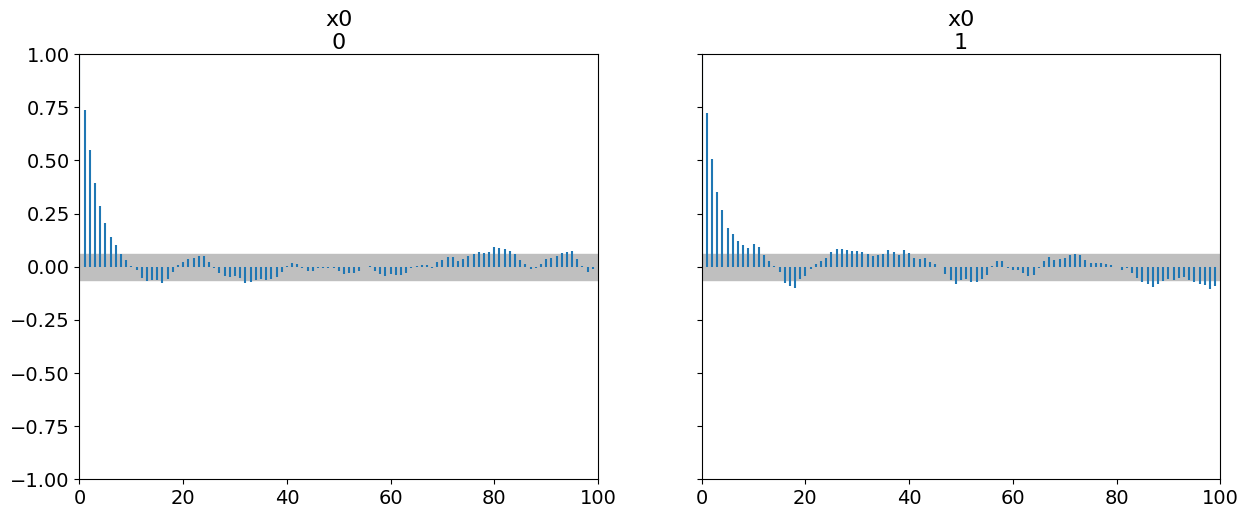

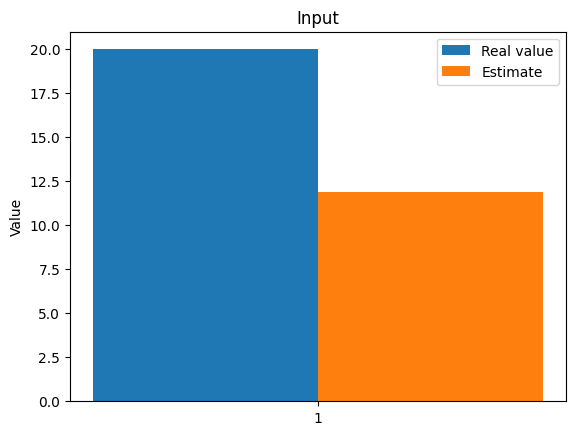

The function param_inverse took 720.9324164390564 seconds.
noise 0.1
nb.data 50
rwmh.scaling 0.1


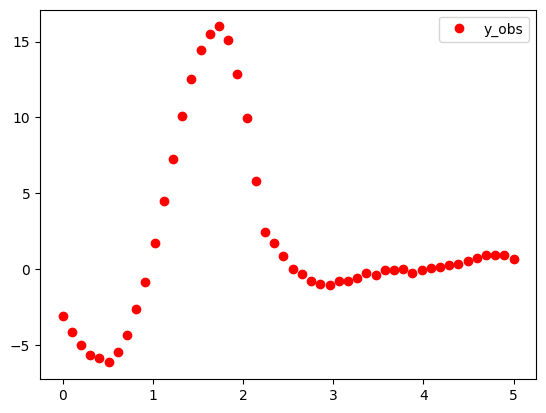

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [05:51<00:00,  5.70it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [03:14<00:00, 10.31it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [11.423]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.423  6.61    4.51   18.567       4.65    3.932       3.0     208.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [8.577]



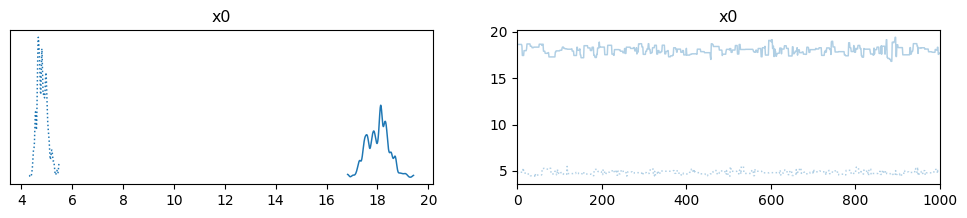

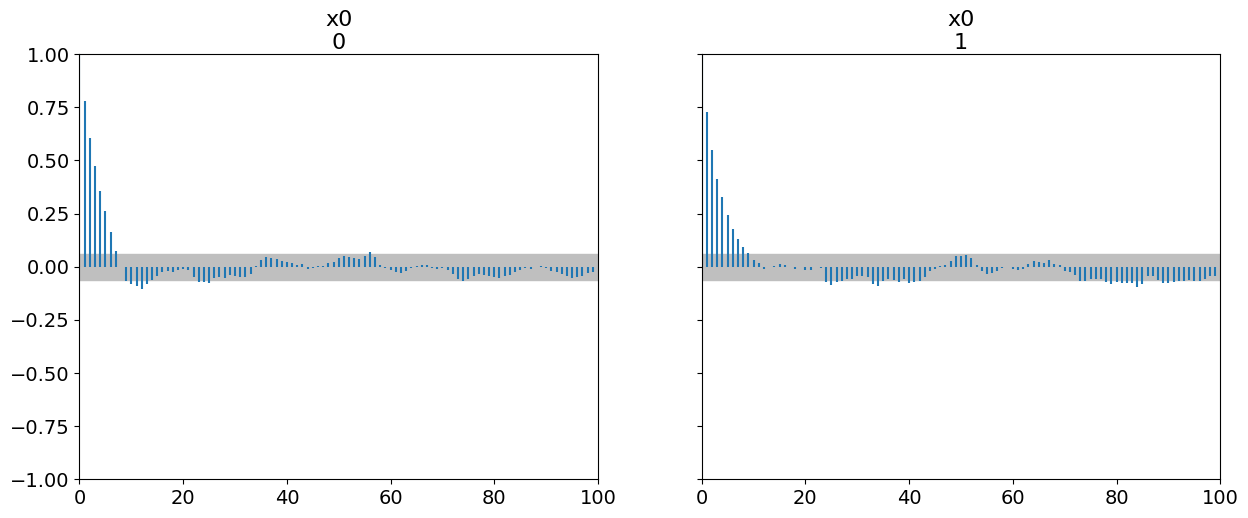

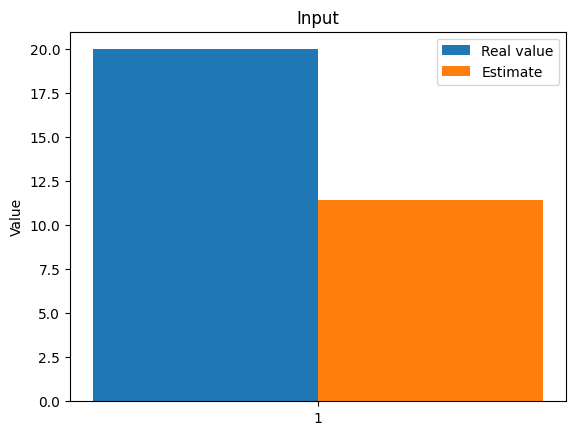

The function param_inverse took 546.1435897350311 seconds.
noise 0.1
nb.data 50
rwmh.scaling 0.1


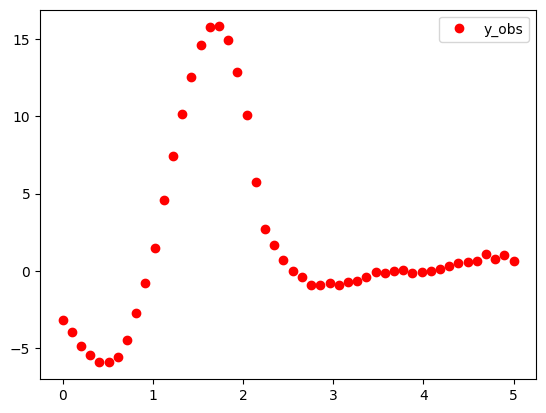

real values are [20.]
Sampling chain 1/2


Running chain, α = 0.20: 100%|██████████| 2000/2000 [03:25<00:00,  9.76it/s]


Sampling chain 2/2


Running chain, α = 0.28: 100%|██████████| 2000/2000 [03:36<00:00,  9.23it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [11.444]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.444  6.604   4.539   18.623      4.648     3.93       3.0     187.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [8.556]



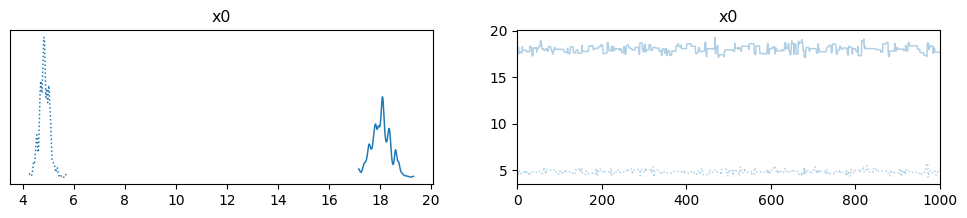

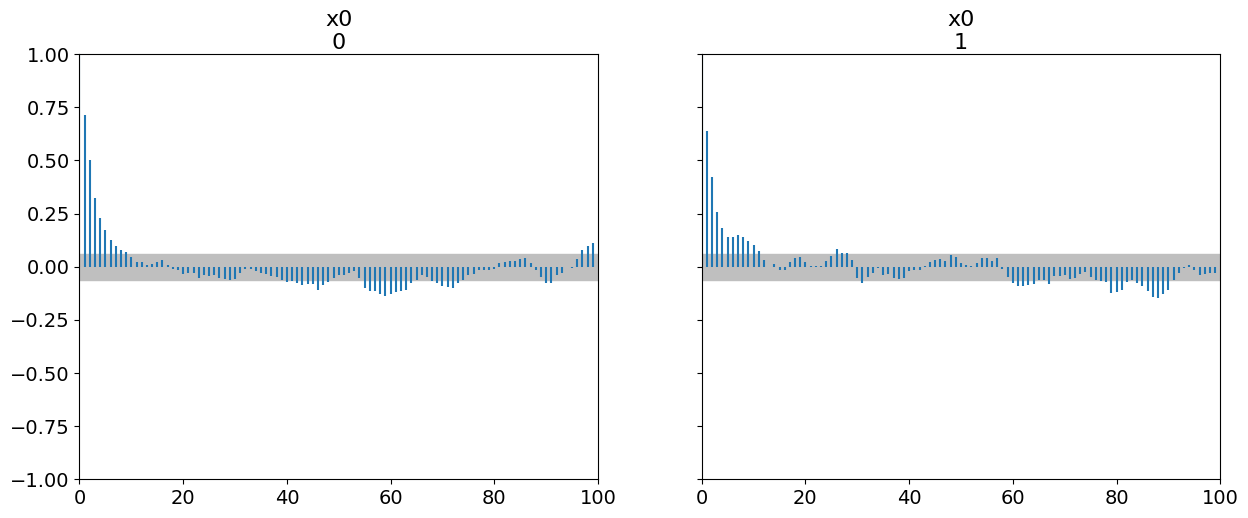

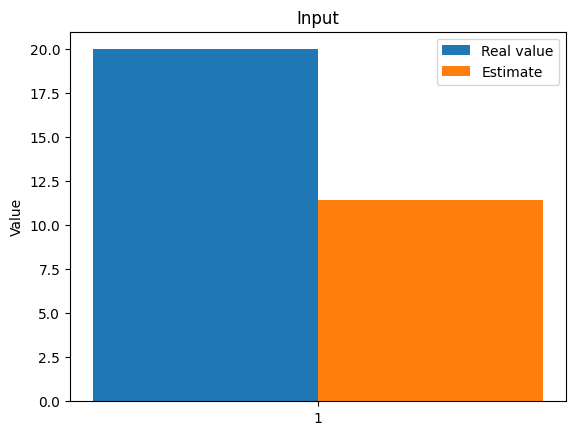

The function param_inverse took 424.0047826766968 seconds.


In [37]:
# true parameters
sigma_noise=[0.1]
n_data=[30,50]
parameters=np.array([20.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([10.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([1.,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")

# MCMC using CuqiPy

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3,4.8])
mean_prior = np.ones(dim)*2.5
sigma=[0.5,1,1.5,2]
sigma_noise=0.1
#rwmh_cov = np.eye(len(real_x)) # !
scale=0.1
iterations =1000
burnin = 550
n_chains=5

In [ ]:
sigma=0.5
estimate_MF_adapt=final_model.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,adapt=False, scale=scale)


In [ ]:
for i in range(len(sigma)):
    estimate_MF=final_model.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma[i]**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


In [ ]:
estimate_LF=modelLF.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


In [ ]:
estimate_HF=modelHF.inverse_cuqi(mean_prior, sd_noise=sigma_noise, proposal_sd=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


# MCMC using tinyDA

In [ ]:
dim=1
#real_x = np.random.rand(dim)*5
#real_x=np.array([0.5,2.,3.,4.5])
real_x=np.array([1,2,3,4])
# Set parameters for the MCMC

mean_prior = np.ones(dim)
cov_prior = np.ones(dim)*5*0.2
sigma=0.7
sigma_noise=0.1
rwmh_cov = np.eye(dim) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=3

In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

In [ ]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(dim), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

# Multifidelity

In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


## High fidelity


In [ ]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)